## 1. Импорты и настройки


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
import hashlib
import warnings
import tarfile
import os
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 30)
pd.set_option('display.max_colwidth', 120)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 13

# Единый список значений, которые считаем пустыми
EMPTY_VALUES = ['', 'nan', 'None', 'NaN']

DATA_PATH     = 'dwh__u_mfgalyavov_student_final.csv'
MICROCAT_PATH = 'dwh_dma_current_microcategories.csv'
OUTPUT_PATH = 'dataset_filtered.csv'

EXCLUDED_CATS = {250006, 250005}  # Вакансии, Грузоперевозки и услуги

## 2. Загрузка и именование колонок

CSV-файл не содержит строки с заголовками. Названия соответствуют документации ментора.

**Колонки для модели:**

| Колонка | Тип | Описание |
|---------|-----|----------|
| `item_id` | int | Уникальный ID объявления |
| `title` | str | Заголовок объявления |
| `description` | str | **Целевая переменная** — текстовое описание |
| `image_id` | int | ID главной фотографии (`images/{image_id}.jpg`) |

**Метаинформация:**

| Колонка | Тип | Описание |
|---------|-----|----------|
| `category_id` | int | ID категории товара |
| `microcat_id` | int | ID микрокатегории |
| `itemstatus_id` | int | Статус: `4`=активно, `12`=продано на Авито, `14`=снято продавцом, `15`=продано в другом месте |
| `price` | float | Цена в рублях |
| `starttime` | datetime | Дата публикации |
| `finishtime` | datetime | Дата снятия / продажи (пусто, если ещё активно) |
| `imagescount` | int | Кол-во фотографий у продавца (в датасете только первая) |
| `isshop` | bool | Продавец — магазин |
| `iscompany` | bool | Продавец — компания |
| `hasbusinessprofile` | bool | Есть бизнес-профиль |
| `reputationscore` | float | Рейтинг продавца 0–1 |
| `user_reg_time` | datetime | Дата регистрации продавца |

> `ismarketplaceseller` — 100% NaN, исключена при загрузке.

**Добавлено при загрузке:** `microcat_name`, `category_name` (join из справочника), `has_image` (наличие фото в архиве).

In [ ]:
df_raw = pd.read_csv(DATA_PATH, header=None, encoding='utf-8', on_bad_lines='skip')
print(f'Загружено: {df_raw.shape[0]:,} строк, {df_raw.shape[1]} колонок')

COLUMNS = [
    'item_id', 'title', 'description', 'image_id', 'category_id',
    'microcat_id', 'itemstatus_id', 'price', 'starttime', 'finishtime',
    'imagescount', 'isshop', 'iscompany', 'hasbusinessprofile',
    'ismarketplaceseller', 'reputationscore', 'user_reg_time'
]

df = df_raw.copy()
df.columns = COLUMNS

# Числовые
for col in ['item_id','image_id','category_id','microcat_id','itemstatus_id','imagescount']:
    df[col] = pd.to_numeric(df[col], errors='coerce')
df['price'] = pd.to_numeric(df['price'], errors='coerce')
df['reputationscore'] = pd.to_numeric(df['reputationscore'], errors='coerce')

# Булевы
for col in ['isshop', 'iscompany', 'hasbusinessprofile']:
    df[col] = df[col].map({'true': True, 'false': False, True: True, False: False})

# Даты
for col in ['starttime', 'finishtime', 'user_reg_time']:
    df[col] = pd.to_datetime(df[col], errors='coerce')
df['created_year'] = df['starttime'].dt.year

# Текст
df['title']       = df['title'].astype(str)
df['description'] = df['description'].astype(str)

Загружено: 300,000 строк, 17 колонок


In [ ]:
# Микрокатегории. Совсем микро есть не для каждой категории в справочнике
mcdf = pd.read_csv(MICROCAT_PATH, header=None,
    names=['cat_id_ref','category_name','microcat_id',
           'microcat_subcat','microcat_type1','microcat_name'])
mcdf['microcat_id'] = mcdf['microcat_id'].astype('int64')
df['microcat_id']   = df['microcat_id'].astype('Int64')
df = df.merge(
    mcdf[['microcat_id','microcat_name','category_name','microcat_subcat']].drop_duplicates('microcat_id'),
    on='microcat_id', how='left'
)
df['microcat_name'] = df['microcat_name'].fillna('Неизвестная микрокатегория')
df['category_name'] = df['category_name'].fillna('Неизвестная категория')

cat_cov  = df['category_name'].ne('Неизвестная категория').mean() * 100
mcat_cov = df['microcat_name'].ne('Неизвестная микрокатегория').mean() * 100
print(f'Покрытие category_name:  {cat_cov:.1f}%  (крупная группа)')
print(f'Покрытие microcat_name:  {mcat_cov:.1f}%  (конкретная подкатегория)')


Покрытие category_name:  100.0%  (крупная группа)
Покрытие microcat_name:  90.0%  (конкретная подкатегория)


In [ ]:
# Наличие изображения в архиве
IMAGE_ARCHIVE = 'student_dataset_images.tar.gz'
available_ids = set()
with tarfile.open(IMAGE_ARCHIVE, 'r:gz') as tar:
    for m in tar.getmembers():
        fname = m.name.split('/')[-1]
        if fname.endswith('.jpg'):
            try: available_ids.add(int(fname[:-4]))
            except ValueError: pass
df['has_image'] = df['image_id'].isin(available_ids)
print(f'Изображений в архиве:  {len(available_ids):,}')
print(f'Строк с изображением:  {df["has_image"].sum():,} ({df["has_image"].mean()*100:.1f}%)')

print(df.dtypes)

Изображений в архиве:  262,776
Строк с изображением:  262,776 (87.6%)
item_id                         int64
title                          object
description                    object
image_id                        int64
category_id                     int64
microcat_id                     Int64
itemstatus_id                   int64
price                         float64
starttime              datetime64[ns]
finishtime             datetime64[ns]
imagescount                     int64
isshop                         object
iscompany                        bool
hasbusinessprofile             object
ismarketplaceseller           float64
reputationscore               float64
user_reg_time          datetime64[ns]
created_year                    int32
microcat_name                  object
category_name                  object
microcat_subcat                object
has_image                        bool
dtype: object


Cмотрим на microcat_id

In [ ]:
known_cats = df.loc[df["microcat_name"] != "Неизвестная категория", "category_name"].unique()
spot_names = known_cats[:3]

print("Примеры категорий:")
for cat_name in spot_names:
    cat_rows = df[df["category_name"] == cat_name]
    mid = cat_rows["microcat_id"].mode()[0]
    mcat_label = cat_rows.loc[cat_rows["microcat_id"] == mid, "microcat_name"].iloc[0]
    sample = cat_rows.loc[cat_rows["microcat_id"] == mid, ["title","description"]].head(3)
    print(f"\ncategory: {cat_name} | microcat_id: {mid} | microcat_name: {mcat_label}")
    for _, row in sample.iterrows():
        print(f"  title: {row['title'][:70]}")
        print(f"  desc:  {str(row['description'])[:100]}")
        print()


Примеры категорий:

category: Для дома и дачи | microcat_id: 242818500002 | microcat_name: Пиломатериалы
  title: Планкен 20*125*3000 ав
  desc:  Планкен 20*125*3000 АВ 
— Всегда есть в наличии!
— Гарантия соответствия цены!
— Гарантия качества!


  title: Доска, Брус, Лес сосна
  desc:  У нас широкий выбор сечения и пород дерева,оптовые поставки.📦 Строганные доски из сосны от производи

  title: Лес, Брус, Доска 2 сорт доставка
  desc:  👋Доброго времени суток!👋

✅У нас Вы сможете приобрести довольно огромный каталог пилопродукцийℹ:
🍃до


category: Личные вещи | microcat_id: 1673 | microcat_name: Кофты и футболки
  title: Зип худи Поло Ральф Лаурен (Код артикула: 72877)
  desc:  Зипка Polo Ralph Lauren / Кофта Polo Ralph Lauren

➡️ Лучшее качество на рынке

➡️ Лучшая детализаци

  title: Худи Alpha Industries EMB
  desc:  Худи Alpha Industries EMB

Ru shopping это:

✅ Строго оригинальный товар. Поставки только из Германи

  title: Кофта Adidas japan лимитированная
  desc:  ❗Кофта Adida

## 3. Пропущенные значения

Анализируем, в каких колонках есть пропуски и в какой доле. Это важно для понимания, какие признаки можно использовать в качестве возможных фичей.

Колонки с пропусками:


,null_count,null_percent
ismarketplaceseller,300000,100.0000
isshop,220171,73.3900
reputationscore,155884,51.9600
hasbusinessprofile,21501,7.1700


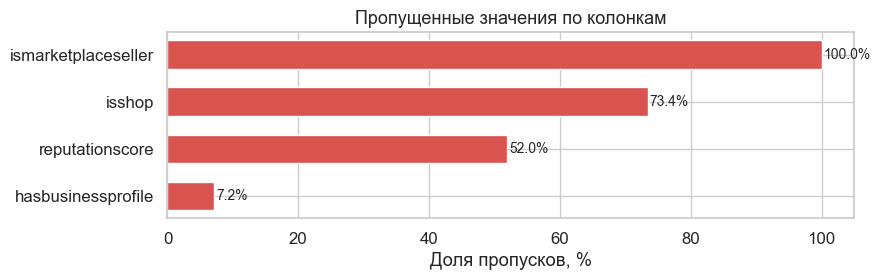

In [ ]:
missing = pd.DataFrame({
    'null_count': df.isnull().sum(),
    'null_percent':   (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values('null_percent', ascending=False)

missing_nonzero = missing[missing['null_count'] > 0]

print('Колонки с пропусками:')
display(missing_nonzero)

fig, ax = plt.subplots(figsize=(9, max(3, len(missing_nonzero) * 0.45)))
vals = missing_nonzero['null_percent'].sort_values()
bars = ax.barh(vals.index, vals.values, color='#d9534f', edgecolor='white', height=0.6)
for bar, v in zip(bars, vals.values):
    ax.text(v + 0.3, bar.get_y() + bar.get_height() / 2, f'{v:.1f}%', va='center', fontsize=10)
ax.set_xlabel('Доля пропусков, %')
ax.set_title('Пропущенные значения по колонкам')
plt.tight_layout()
plt.show()


In [ ]:
# Распределение булевых признаков (до fillna)
print("Распределение булевых признаков:\n")
for col in ['isshop', 'iscompany', 'hasbusinessprofile']:
    vc = df[col].value_counts(dropna=False).rename({True: 'True', False: 'False', float('nan'): 'NaN'})
    total = len(df)
    print(f"{col}:")
    for val, cnt in vc.items():
        print(f"  {str(val):5s}  {cnt:>7,}  ({cnt/total*100:.1f}%)")
    print()


Распределение булевых признаков:

isshop:
  nan    220,171  (73.4%)
  False   71,796  (23.9%)
  True     8,033  (2.7%)

iscompany:
  True   179,115  (59.7%)
  False  120,885  (40.3%)

hasbusinessprofile:
  False  162,538  (54.2%)
  True   115,961  (38.7%)
  nan     21,501  (7.2%)



## 4. Стратегия обработки пропусков

* `ismarketplaceseller` (100% пропусков) — полностью удаляем, т.к. колонка пустая, данных нет и пользы тоже.
* `reputationscore` (52% пропусков) — оставляем NaN. Пропуск означает, что продавец новый и заказов ещё не было. В формуле `quality_score` дадим им нейтральный вес 0.5.
* `isshop` (73% пропусков) — оставляем NaN. Дыра в данных слишком большая, чтобы просто заполнить её False.
* **`hasbusinessprofile` (7% пропусков)** — заполняем через `fillna(False)`. Пропусков мало, а по распределению там почти везде `False`.

Для `reputationscore` и `isshop` сглаживаем пропуски нейтральным весом 0.5 в итоговом `quality_score`.

In [ ]:
df = df.drop(columns=['ismarketplaceseller'])   # 100% NaN — бесполезна
df['hasbusinessprofile'] = df['hasbusinessprofile'].fillna(False)

## 5. Целевая переменная: описание

Описание — это то, что модель должна генерировать. Анализируем его длину, структуру и качество.

Три метрики длины:
- Количество символов — грубая оценка объёма текста.
- Количество слов — основная метрика при обучении генеративных моделей.
- Количество предложений — показывает структурность.

In [ ]:
df_desc = df.copy()

df_desc['desc_len_chars'] = df_desc['description'].str.len()
df_desc['desc_len_words'] = df_desc['description'].apply(
    lambda x: len([t for t in re.split(r'[\s,;.!?|:]+', x)
                   if re.sub(r'^\W+|\W+$', '', t)])
)
df_desc['desc_num_sentences'] = df_desc['description'].str.count(r'[.!?]+')

stats = df_desc[['desc_len_chars', 'desc_len_words', 'desc_num_sentences']].describe(
    percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95]).T
stats.columns = ['n', 'mean', 'std', 'min', 'p10', 'p25', 'p50', 'p75', 'p90', 'p95', 'max']
print('Статистика длины описаний:')
display(stats.round(1))

Статистика длины описаний:


,n,mean,std,min,p10,p25,p50,p75,p90,p95,max
desc_len_chars,300000.0000,1031.7000,889.1000,51.0000,108.0000,283.0000,883.0000,1433.0000,2226.0000,2769.0000,4999.0000
desc_len_words,300000.0000,138.2000,118.0000,3.0000,16.0000,40.0000,118.0000,192.0000,295.0000,367.0000,989.0000
desc_num_sentences,300000.0000,10.8000,10.3000,0.0000,1.0000,3.0000,8.0000,16.0000,22.0000,29.0000,311.0000


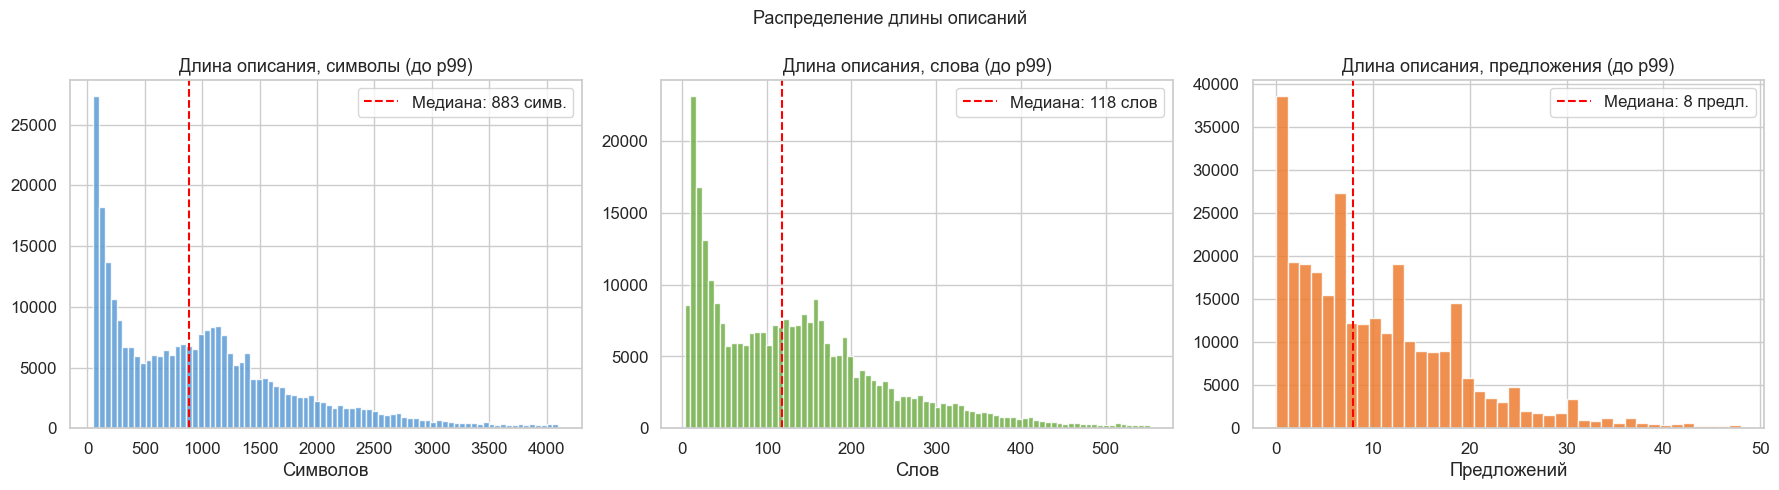

In [ ]:
p99_chars = df_desc['desc_len_chars'].quantile(0.99)
p99_words = df_desc['desc_len_words'].quantile(0.99)
p99_sent  = df_desc['desc_num_sentences'].quantile(0.99)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(
    df_desc.loc[df_desc['desc_len_chars'] <= p99_chars, 'desc_len_chars'],
    bins=80, color='#5b9bd5', edgecolor='white', alpha=0.85
)
axes[0].axvline(df_desc['desc_len_chars'].median(), color='red', linestyle='--',
                label=f'Медиана: {df_desc["desc_len_chars"].median():.0f} симв.')
axes[0].set_title('Длина описания, символы (до p99)')
axes[0].set_xlabel('Символов')
axes[0].legend()

axes[1].hist(
    df_desc.loc[df_desc['desc_len_words'] <= p99_words, 'desc_len_words'],
    bins=80, color='#70ad47', edgecolor='white', alpha=0.85
)
axes[1].axvline(df_desc['desc_len_words'].median(), color='red', linestyle='--',
                label=f'Медиана: {df_desc["desc_len_words"].median():.0f} слов')
axes[1].set_title('Длина описания, слова (до p99)')
axes[1].set_xlabel('Слов')
axes[1].legend()

axes[2].hist(
    df_desc.loc[df_desc['desc_num_sentences'] <= p99_sent, 'desc_num_sentences'],
    bins=40, color='#ed7d31', edgecolor='white', alpha=0.85
)
axes[2].axvline(df_desc['desc_num_sentences'].median(), color='red', linestyle='--',
                label=f'Медиана: {df_desc["desc_num_sentences"].median():.0f} предл.')
axes[2].set_title('Длина описания, предложения (до p99)')
axes[2].set_xlabel('Предложений')
axes[2].legend()

plt.suptitle('Распределение длины описаний', fontsize=13)
plt.tight_layout()
plt.show()

### Примеры описаний

In [ ]:
print('Самые короткие описания (по числу слов):')
shortest = df_desc.nsmallest(8, 'desc_len_words')[['title', 'description', 'desc_len_words']]
display(shortest)

Самые короткие описания (по числу слов):


,title,description,desc_len_words
197639,Ремкомплект двс Полный (K1+K2) 6D155-4 6128K12207,6128K12207/6128-K1-2207/Komatsu S6D155-4 SA6D155-4,3
88597,Дифференциальный автоматический выключательузо,Дифференциальный автоматический выключатель MDV10-2-040-300,4
114550,Удаленная работа,"Ответственная, трудолюбивая, коммуникабельная, стрессоустойчивая",4
155041,Администратор,"адекватная,стрессоустойчивая,инициативная,коммуникабельная.",4
208935,Создание событийно-управляемых микросервисов,Создание событийно-управляемых микросервисов Беллемар,4
263135,Гидромотор azpf-10-008RCB20MB арт. 0510425009/R918C00356,Гидромотор AZPF-10-008RCB20MB арт. 0510425009/R918C00356,4
267104,Администратор/менеджер,"Внимательность, ответственность, многозадачность, исполнительность",4
3546,Детский матрас 160 70,Хорошее состояние. Пружинный. \nБесплатно. Самовывоз,5


In [ ]:
p95_words = df_desc['desc_len_words'].quantile(0.95)
long_desc = df_desc[df_desc['desc_len_words'] >= p95_words]

print(f'Самые длинные описания (>= p95, от {p95_words:.0f} слов): {len(long_desc):,} объявлений')
print(f'Максимум: {df_desc["desc_len_words"].max()} слов\n')

for _, row in long_desc.sample(3, random_state=42).iterrows():
    print(f'Заголовок: {row["title"]}')
    print(f'Слов: {row["desc_len_words"]}')
    print(f'Описание:\n{row["description"]}')
    print('-' * 60)

Самые длинные описания (>= p95, от 367 слов): 15,093 объявлений
Максимум: 989 слов

Заголовок: Переезд междугородний на газели. Грузоперевозки
Слов: 391
Описание:
🚚Переезд междугородний на газели. Грузоперевозки🚚

Перевезу ваш груз между городами быстро и аккуратно. Работаю без посредников — лично контролирую каждый рейс, машину подаю вовремя, соблюдаю договорённые сроки и прозрачные условия. При возможности подберу попутный рейс, чтобы сэкономить ваши деньги.

🚚 Автопарк и оснащение
Тентовые автомобили 3–5 тонн с боковой и задней погрузкой, имеются крепления и стяжные ремни. Кузова содержатся в чистоте, техника исправна, регулярное обслуживание. По запросу возможна опломбировка.

🕒 Маршруты и сроки
Осуществляю междугородние перевозки по всей стране. Подстраиваю рейсы под нужные даты: срочные отправки, ночные и дневные рейсы, работа по выходным. Предложу несколько вариантов времени подачи и оптимальный маршрут с учётом пробок и состояния дорог.

📦 Перевозимые грузы
Стройматериалы, обор

In [ ]:
q25 = df_desc['desc_len_words'].quantile(0.25)
q75 = df_desc['desc_len_words'].quantile(0.75)
typical = df_desc[(df_desc['desc_len_words'] >= q25) & (df_desc['desc_len_words'] <= q75)]

print(f'Примеры типичных описаний ({q25:.0f}–{q75:.0f} слов):')
for _, row in typical.sample(3, random_state=42).iterrows():
    print(f'\nЗаголовок: {row["title"]}')
    print(f'Описание:  {row["description"][:400]}')
    print('-' * 60)

Примеры типичных описаний (40–192 слов):

Заголовок: 2-к. квартира, 40,2 м², 14/18 эт.
Описание:  Сдаётся 2-х комнатная квартира, от собственника. Новостройка, жилой комплекс комфорт-класса.
В квартире две отдельные комнаты площадью 12 и 9 кв.м. и кухня 12 кв.м. Просторная лоджия.
До ст. метро Девяткино 20 минут пешком. От метро ходит маршрутка, остановка рядом с домом.
Закрытая охраняемая придомовая территория. Во дворе имеется  детская и спортивная площадка. Рядом с домом есть продуктовые
------------------------------------------------------------

Заголовок: iPhone 16 Pro Max дисплей оригинал новый
Описание:  Дисплей новый сервисный оригинал, так же в наличии б/у оригинал в идеальном состоянии.
Возможна срочная установка при вас
По другим вопросам звоните, задавайте вопросы на Avito
Так же есть в наличии другие запчасти iPhone, шлейфа, камеры, корпус, оригинал и копии высокого качества.
Восстановление данных, сложный ремонт материнских плат  с утопленных, разбитых телефонов  и т.д.

### Паттерны, снижающие качество описания

Нужно убрать описания, которые не несут информации о товаре: контакты продавца, ссылки на внешние ресурсы, спамные призывы к действию. Такие описания точно не являются образцом хорошего текста.

In [ ]:
patterns = {
    'Внешние ссылки (http, www)':                      r'(http|www\.)',
    'Соцсети и мессенджеры (vk.com, t.me, whatsapp)':  r'(vk\.com|t\.me|whatsapp\.com|вотсап|viber\.com)',
    'Прямые контакты (@, +7, 8-9xx)':                  r'(@|\+7|8[- ]?\(?\d{3}\)?[\s\-]?\d)',
}

print('Доля описаний с нежелательными паттернами:')
for name, pattern in patterns.items():
    mask = df_desc['description'].str.contains(pattern, case=False, regex=True, na=False)
    print(f'  {name}: {mask.sum():,} ({mask.mean()*100:.1f}%)')

Доля описаний с нежелательными паттернами:
  Внешние ссылки (http, www): 24 (0.0%)
  Соцсети и мессенджеры (vk.com, t.me, whatsapp): 60 (0.0%)
  Прямые контакты (@, +7, 8-9xx): 28,587 (9.5%)


In [ ]:
comm_pattern = r'\b(звоните|позвоните|пишите|пиши|звони)\b'
comm_mask = df_desc['description'].str.contains(comm_pattern, case=False, regex=True, na=False)
print(f'Доля описаний с призывами к коммуникации: {comm_mask.sum():,} ({comm_mask.mean()*100:.1f}%)')

Доля описаний с призывами к коммуникации: 114,623 (38.2%)


В дальнейшем стоит исключить внешние ссылки, соцсети и прямые номера телефонов — их суммарно около 10%. Просто призывы звонить это ок

### Топ слов в описаниях

Смотрим на частотное распределение слов, чтобы понять тематику и лексику датасета. Стоп-слова (предлоги, союзы, местоимения) исключаем — они не несут предметного смысла. Анализ ведём на случайной выборке из 10000 объявлений, чтобы не считать весь датасет.

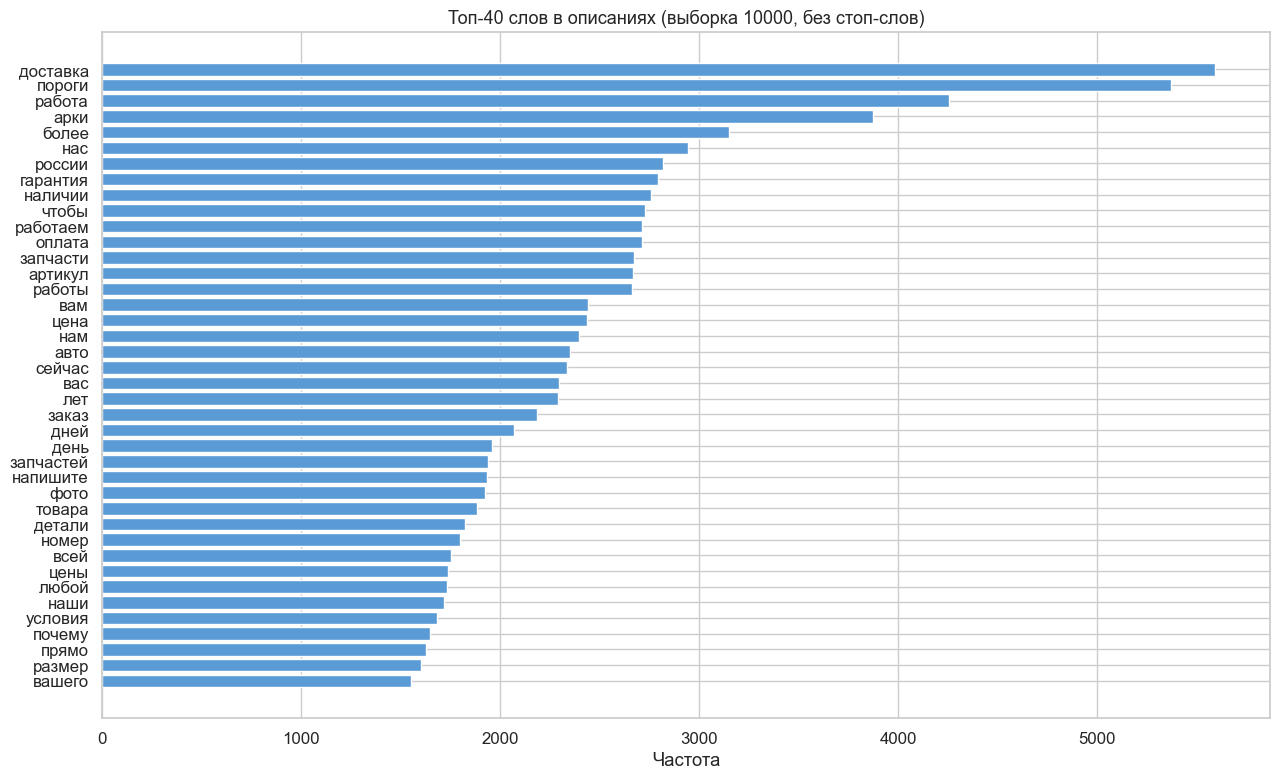

Уникальных слов длиной от 3 символов в выборке: 66,489


In [ ]:
STOPWORDS = {
    'и', 'в', 'на', 'с', 'по', 'для', 'не', 'а', 'или', 'но', 'из', 'к', 'от', 'за',
    'до', 'как', 'что', 'это', 'все', 'так', 'он', 'она', 'они', 'мы', 'вы', 'я',
    'то', 'же', 'если', 'у', 'да', 'уже', 'ещё', 'без', 'под', 'над', 'об', 'про',
    'через', 'будет', 'есть', 'был', 'была', 'были', 'быть', 'можно', 'нет', 'также',
    'только', 'ваш', 'наш', 'его', 'после', 'при', 'со', 'авито', 'звоните', 'пишите',
    'звони', 'пиши'
}

sample_desc = df_desc['description'].sample(10000, random_state=42)
all_words = []
for text in sample_desc:
    words = re.findall(r'[а-яёА-ЯЁ]{3,}', text.lower())
    all_words.extend(w for w in words if w not in STOPWORDS)

word_freq = Counter(all_words)
top40 = pd.DataFrame(word_freq.most_common(40), columns=['word', 'count'])

fig, ax = plt.subplots(figsize=(13, 8))
ax.barh(top40['word'][::-1], top40['count'][::-1], color='#5b9bd5', edgecolor='white')
ax.set_title('Топ-40 слов в описаниях (выборка 10000, без стоп-слов)')
ax.set_xlabel('Частота')
plt.tight_layout()
plt.show()
print(f'Уникальных слов длиной от 3 символов в выборке: {len(word_freq):,}')

## 6. Заголовок

Заголовок — основной входной признак для бейзлайна. Смотрим на его длину: слишком короткие заголовки могут быть неинформативными входами для модели.

Статистика длины заголовков:


,title_len_chars,title_len_words
count,300000.0000,300000.0000
mean,34.9000,5.3000
std,14.3000,2.3000
min,1.0000,1.0000
10%,17.0000,3.0000
25%,25.0000,4.0000
50%,34.0000,5.0000
75%,44.0000,7.0000
90%,50.0000,8.0000
95%,56.0000,9.0000


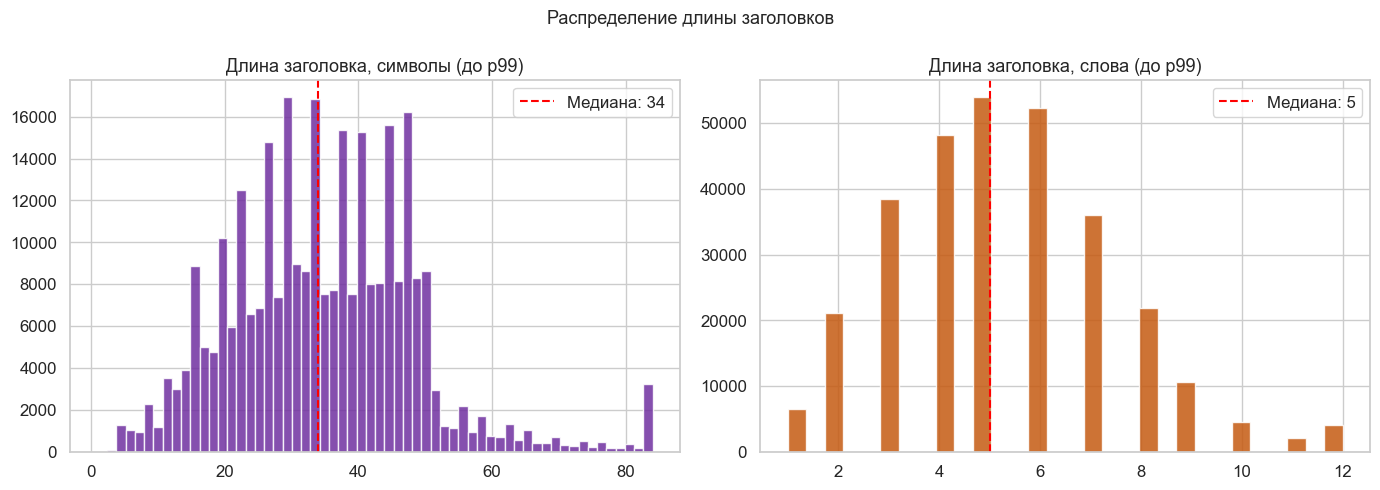

In [ ]:
df['title_len_chars'] = df['title'].str.len()
df['title_len_words'] = df['title'].str.split().str.len()

print('Статистика длины заголовков:')
display(df[['title_len_chars', 'title_len_words']].describe(
    percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95]
).round(1))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

p99_tc = df['title_len_chars'].quantile(0.99)
axes[0].hist(df['title_len_chars'].clip(upper=p99_tc), bins=60,
             color='#7030a0', edgecolor='white', alpha=0.85)
axes[0].axvline(df['title_len_chars'].median(), color='red', linestyle='--',
                label=f'Медиана: {df["title_len_chars"].median():.0f}')
axes[0].set_title('Длина заголовка, символы (до p99)')
axes[0].legend()

p99_tw = df['title_len_words'].quantile(0.99)
axes[1].hist(df['title_len_words'].clip(upper=p99_tw), bins=30,
             color='#c55a11', edgecolor='white', alpha=0.85)
axes[1].axvline(df['title_len_words'].median(), color='red', linestyle='--',
                label=f'Медиана: {df["title_len_words"].median():.0f}')
axes[1].set_title('Длина заголовка, слова (до p99)')
axes[1].legend()

plt.suptitle('Распределение длины заголовков', fontsize=13)
plt.tight_layout()
plt.show()

Выводы по заголовкам:
  Медиана длины:      34 символов / 5 слов
  Диапазон (p1–p99):  7–84 символов

  На графике символов виден локальный минимум около 50 символов, после которого данные продолжаются до ~84. Жёсткого лимита нет — скорее два стиля: короткие заголовки (~30–35 символов, основная масса) и развёрнутые (~55–80 символов).
  Большинство продавцов укладываются в 4–6 слов (медиана 5).

  Заголовок лишь часть входа модели, вместе с категорией, ценой, состоянием товара и фотографиями даже короткий заголовок даёт достаточно контекста для генерации.

## 7. Категории

Категория — важный признак для входа модели: стиль описания сильно зависит от типа товара. Теперь у нас есть реальные названия из справочника (`category_name` и `microcat_name`). Смотрим на распределение по крупным категориям и медианную длину описания.

### Нетоварные категории для исключения
- **Услуги** (`category_id` 250005) — объявления об услугах, не товарах
- **Работа** (`category_id` 250006, 250004) — вакансии
- **Подработка** (`category_id` 654425000001) — разовая работа
- **Готовый бизнес** (`microcat_subcat == "Готовый бизнес"`) — продажа бизнеса целиком; нетипичные описания; **"Оборудование для бизнеса" остаётся** — физические товары
- **Билеты и путешествия** (`microcat_subcat == "Билеты и путешествия"` в Хобби) — впечатления/события, не физические товары; **остальной Хобби остаётся** (велосипеды, спортинвентарь, книги, коллекции)

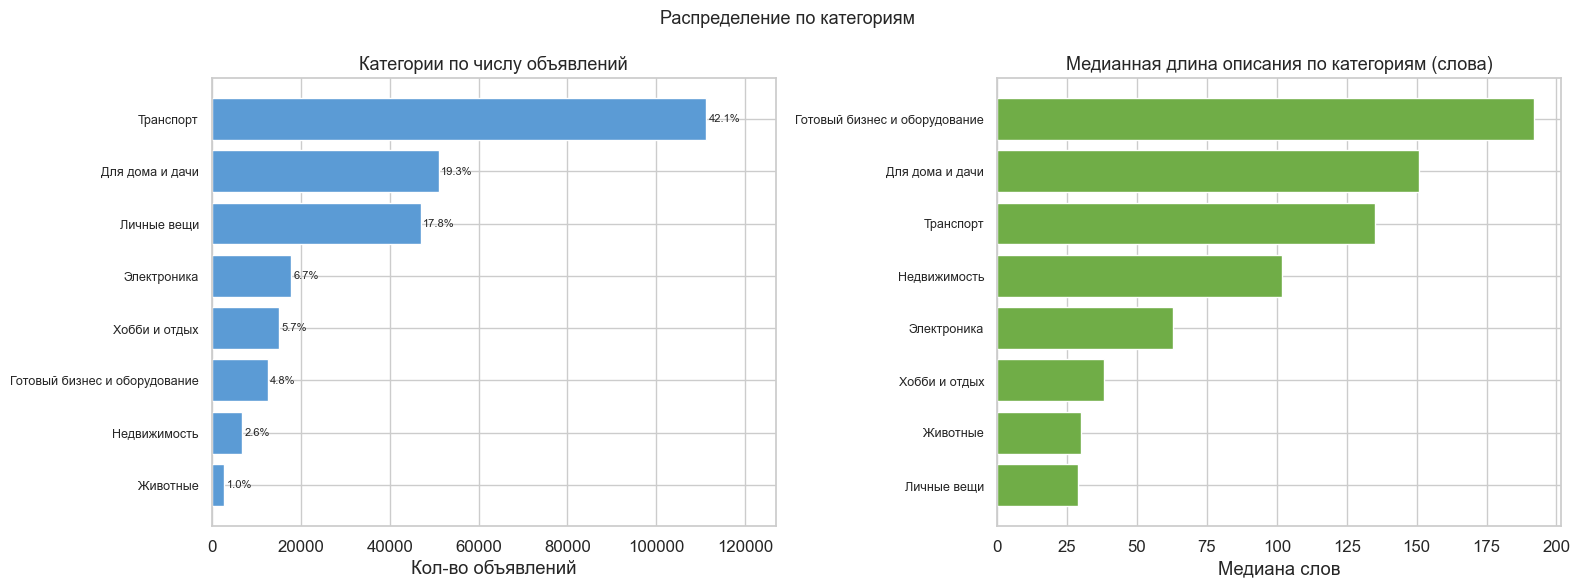

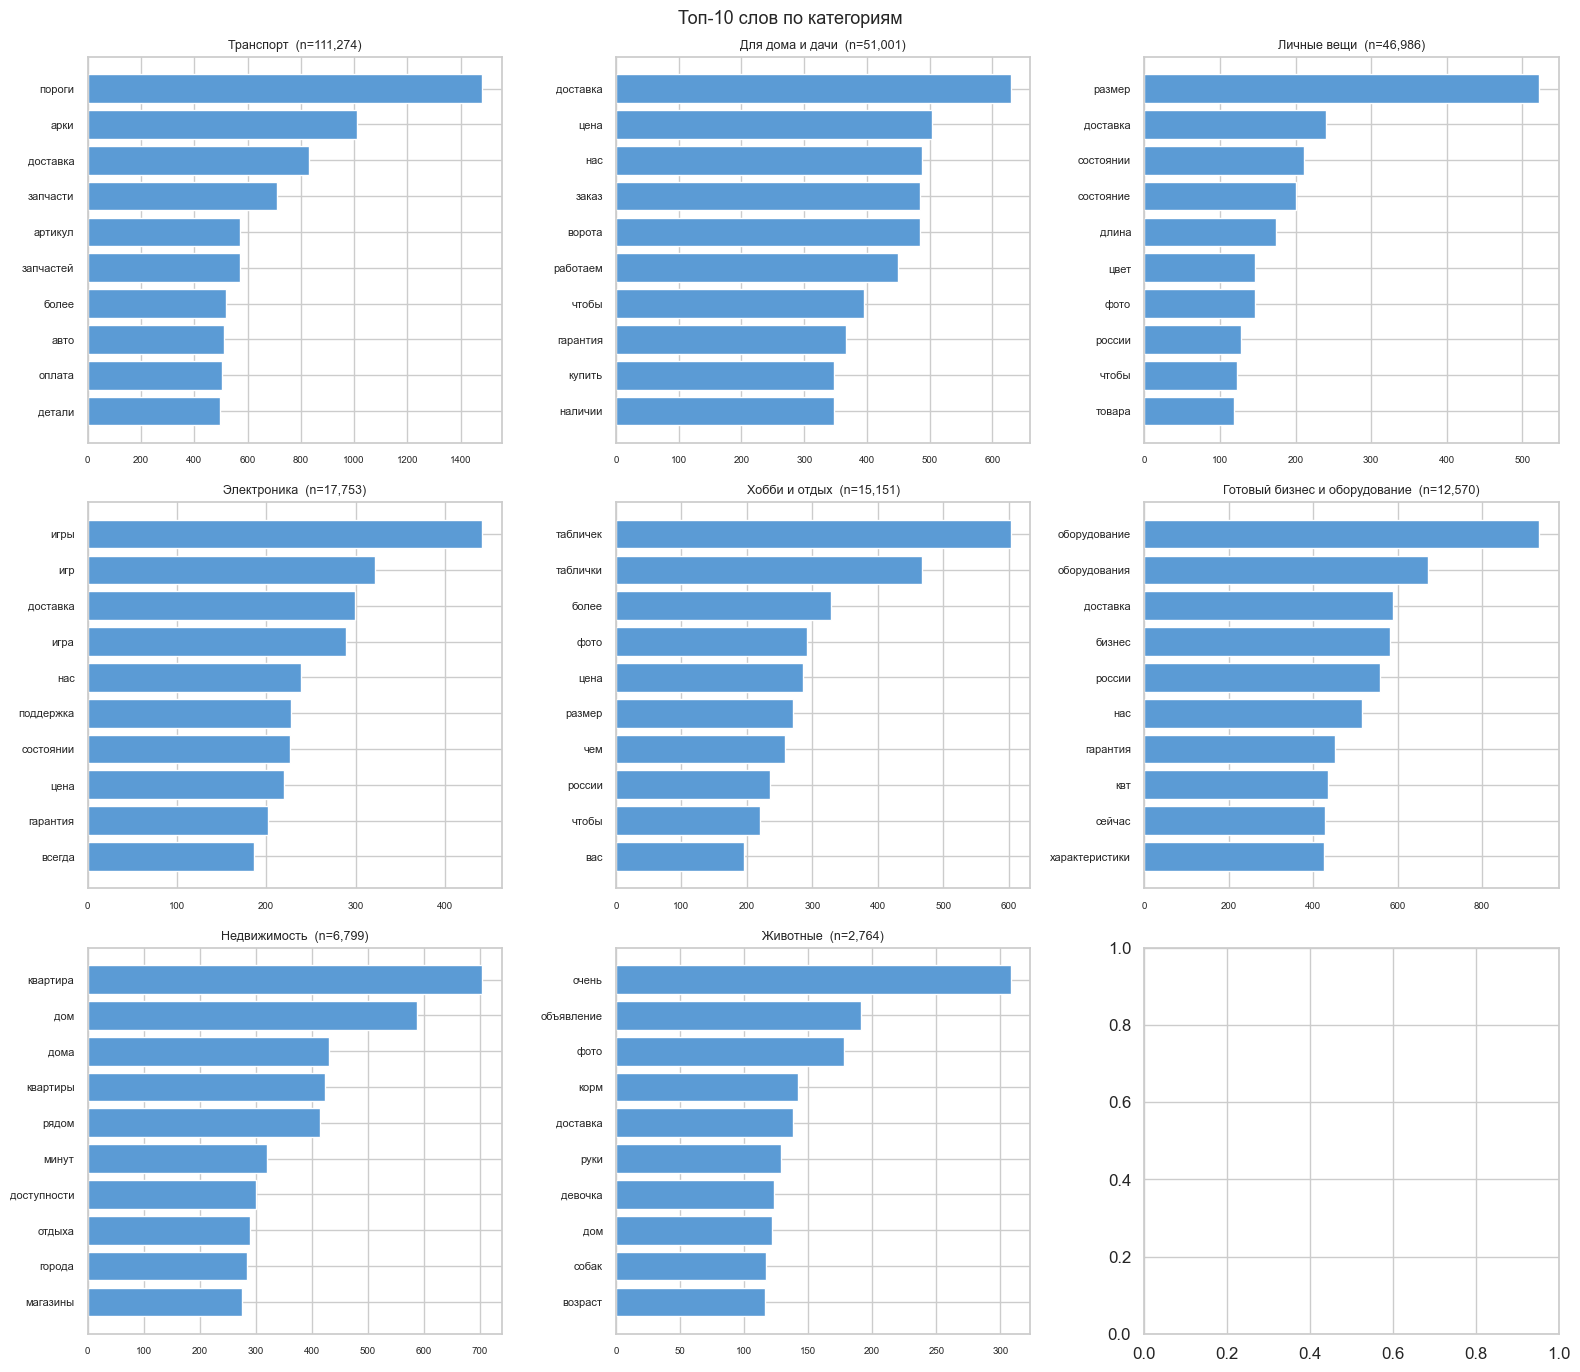

In [ ]:
EXCLUDED_CATS = {250005, 250006, 250004, 654425000001}  # Услуги, Работа, Подработка
EXCL_SUBCAT   = {'Готовый бизнес', 'Билеты и путешествия'}

mask_filt = ~df["category_id"].isin(EXCLUDED_CATS) & ~df["microcat_subcat"].isin(EXCL_SUBCAT)
df_filt7  = df[mask_filt]

cat_counts = df_filt7["category_name"].value_counts()
cat_desc_len = (
    df_filt7
    .merge(df_desc[["item_id","desc_len_words"]], on="item_id", how="left")
    .groupby("category_name")["desc_len_words"]
    .median()
    .reindex(cat_counts.index)
    .sort_values()
    .dropna()
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
total = len(df_filt7)

axes[0].barh(cat_counts.index[::-1], cat_counts.values[::-1],
             color="#5b9bd5", edgecolor="white")
for bar, cnt in zip(axes[0].patches, cat_counts.values[::-1]):
    axes[0].text(bar.get_width() + total*0.002,
                 bar.get_y() + bar.get_height()/2,
                 f"{cnt/total*100:.1f}%", va="center", fontsize=8)
axes[0].set_title("Категории по числу объявлений")
axes[0].set_xlabel("Кол-во объявлений")
axes[0].tick_params(axis="y", labelsize=9)
axes[0].set_xlim(0, cat_counts.max() * 1.14)

axes[1].barh(cat_desc_len.index, cat_desc_len.values,
             color="#70ad47", edgecolor="white")
axes[1].set_title("Медианная длина описания по категориям (слова)")
axes[1].set_xlabel("Медиана слов")
axes[1].tick_params(axis="y", labelsize=9)

plt.suptitle("Распределение по категориям ", fontsize=13)
plt.tight_layout()
plt.show()

def cat_label(cat_id):
    rows = df[df["category_id"] == cat_id]
    return rows["category_name"].iloc[0] if len(rows) else "?"

# Топ-10 слов по топ-9 категориям
top9_cats = cat_counts.head(9).index

fig, axes = plt.subplots(3, 3, figsize=(16, 14))
axes = axes.flatten()

for i, cat_name in enumerate(top9_cats):
    cat_texts = df_desc[df_desc["category_name"] == cat_name]["description"]
    if len(cat_texts) > 1000:
        cat_texts = cat_texts.sample(1000, random_state=42)
    cat_words = []
    for text in cat_texts:
        words = re.findall(r"[а-яёА-ЯЁ]{3,}", text.lower())
        cat_words.extend(w for w in words if w not in STOPWORDS)
    top10 = pd.DataFrame(Counter(cat_words).most_common(10), columns=["word","count"])
    n = len(df_filt7[df_filt7["category_name"] == cat_name])
    axes[i].barh(top10["word"][::-1], top10["count"][::-1], color="#5b9bd5", edgecolor="white")
    axes[i].set_title(f"{cat_name}  (n={n:,})", fontsize=9)
    axes[i].tick_params(axis="y", labelsize=8)
    axes[i].tick_params(axis="x", labelsize=7)

plt.suptitle("Топ-10 слов по категориям", fontsize=13)
plt.tight_layout()
plt.show()


Выводы по распределению категорий:

**Дисбаланс:**
  Транспорт занимает **42.1%** пула — почти половина. Без стратификации модель будет смещена в сторону описаний запчастей и аксессуаров.
  Три крупнейшие (Транспорт + Для дома и дачи + Личные вещи) = **79.2%** — остальные 5 категорий делят 20.8%.
  Животные всего **1.0%** и с очень слабыми описаниями — при файнтюне вклад минимальный.

**Длина описания сильно зависит от категории:**
  "Готовый бизнес и оборудование" (~190 слов) — это теперь чисто "Оборудование для бизнеса" (технические характеристики оборудования дают длинные тексты).
  Для дома и дачи (~150 слов) и Транспорт (~130 слов) тоже пишут развёрнуто — много деталей и характеристик.
  Личные вещи (~25 слов) — самые короткие: размер, цвет, состояние — больше нечего сказать.

**Топ слов подтверждают тематику**, но есть аномалии:

  **Транспорт**: "пороги", "арки", "запчасти" — датасет будто бы больше про автозапчасти, а не про сами автомобили.

  **Для дома и дачи**: "доставка", "ворота", "работаем", "гарантия" — B2B-стиль, много магазинов и производителей.

  **Личные вещи**: "размер", "состояние", "длина", "цвет" — типичное описание б/у одежды.

  **Электроника**: "игры"/"игр"/"игра" в топе, скоре всего речь про игровые приставки.

  **Хобби и отдых**: доминируют "табличек"/"таблички", скорее всего аномалия.

  **Недвижимость**: "квартира", "дом", "рядом", "минут" — важна локация, описания объёмные (~100 слов).

  **Животные**: "очень", "объявление", "фото" — описания слабые, много шумовых слов, важнее визуал.

### Микрокатегории внутри категорий

Для каждой из топ-9 категорий — топ-8 микрокатегорий по числу объявлений. Помогает понять однородность категории.

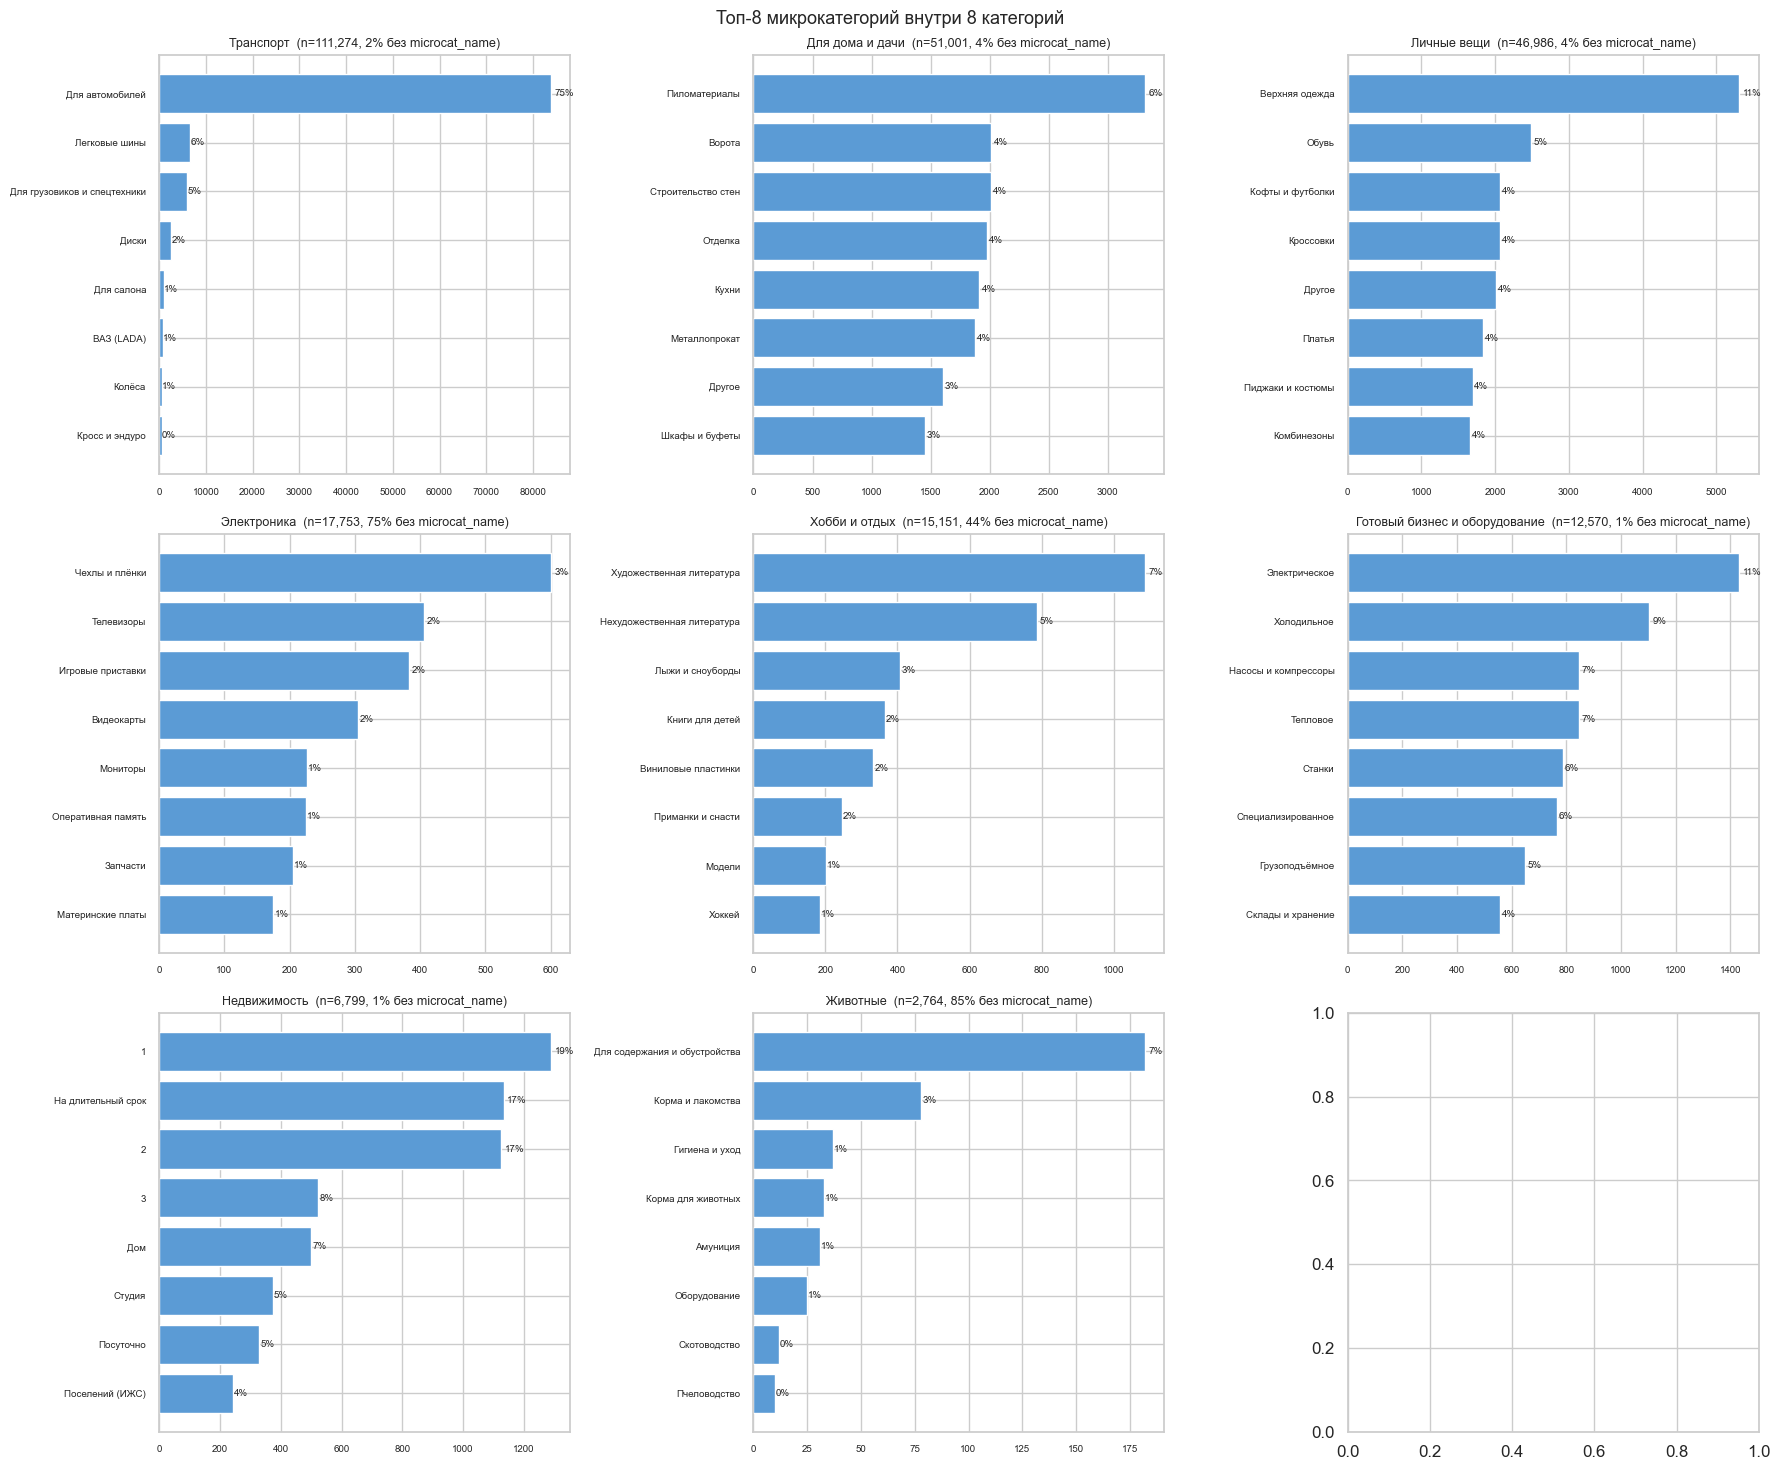

In [ ]:
n_cats    = min(9, len(cat_counts))
top9_cats = cat_counts.head(n_cats).index

fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.flatten()

for idx, cat_name in enumerate(top9_cats):
    cat_rows = df_filt7[df_filt7["category_name"] == cat_name]
    n_total = len(cat_rows)
    known   = cat_rows[cat_rows["microcat_name"] != "Неизвестная микрокатегория"]
    mcat_vc = known["microcat_name"].value_counts().head(8)
    n_unk   = n_total - len(known)

    axes[idx].barh(mcat_vc.index[::-1], mcat_vc.values[::-1],
                   color="#5b9bd5", edgecolor="white")
    for bar, cnt in zip(axes[idx].patches, mcat_vc.values[::-1]):
        axes[idx].text(bar.get_width() * 1.01,
                       bar.get_y() + bar.get_height() / 2,
                       f"{cnt/n_total*100:.0f}%", va="center", fontsize=7)

    unk_str = f", {n_unk/n_total*100:.0f}% без microcat_name" if n_unk else ""
    axes[idx].set_title(f"{cat_name}  (n={n_total:,}{unk_str})", fontsize=9)
    axes[idx].tick_params(axis="y", labelsize=7)
    axes[idx].tick_params(axis="x", labelsize=7)

plt.suptitle(f"Топ-8 микрокатегорий внутри {n_cats} категорий", fontsize=13)
plt.tight_layout()
plt.show()


Выводы по разбивке внутри категорий:

**Транспорт очень однородный:** 75% — "Для автомобилей" (запчасти, аксессуары). Остальные подкатегории (шины, диски, спецтехника) по 1–6%.

**Для дома и дачи — равномерный:** пиломатериалы, ворота, отделка, кухни — по 3–4% каждая. Разнообразие высокое, модель должна научиться разным стилям внутри категории.

**Недвижимость: microcat_name = "1", "2", "3"** — это скорее всего число комнат.

## 8. Цена

Цена — один из входных признаков модели. Обращаем внимание на аномалии: отрицательные значения и экстремально большие числа. Строим распределение в линейном и логарифмическом масштабе — последнее лучше отражает структуру, так как цены сильно правоскошены.

In [ ]:
print('Статистика цен (руб.):')
display(df['price'].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).round(0))
print(f"\nЦена <= 0 или NaN: {((df['price'] <= 0) | df['price'].isna()).sum():,} объявлений")
print(f"Цена > 1 млн:       {(df['price'] > 1_000_000).sum():,} объявлений")
print(f"Цена > 10 млн:      {(df['price'] > 10_000_000).sum():,} объявлений")

Статистика цен (руб.):


count         300000.0000
mean        11706988.0000
std       2965229018.0000
min               -1.0000
10%              300.0000
25%             1000.0000
50%             3100.0000
75%            15900.0000
90%           126000.0000
95%           380000.0000
99%          6190000.0000
max     999999999999.0000
Name: price, dtype: float64


Цена <= 0 или NaN: 8,897 объявлений
Цена > 1 млн:       9,091 объявлений
Цена > 10 млн:      1,379 объявлений


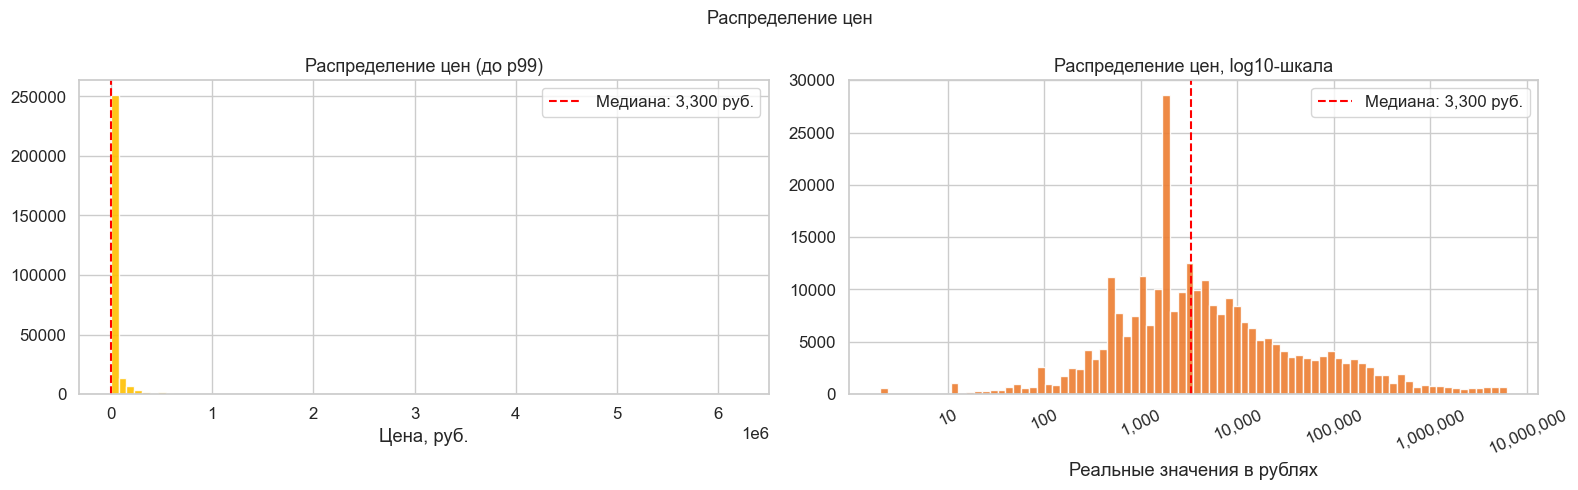

In [ ]:
price_clean = df['price'][(df['price'] > 0) & (df['price'] < df['price'].quantile(0.99))]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].hist(price_clean, bins=80, color='#ffc000', edgecolor='white', alpha=0.9)
axes[0].axvline(price_clean.median(), color='red', linestyle='--',
                label=f'Медиана: {price_clean.median():,.0f} руб.')
axes[0].set_title('Распределение цен (до p99)')
axes[0].set_xlabel('Цена, руб.')
axes[0].legend()

log_p = np.log10(price_clean + 1)
axes[1].hist(log_p, bins=80, color='#ed7d31', edgecolor='white', alpha=0.9)

# Медиана на лог-шкале
log_median = np.log10(price_clean.median() + 1)
axes[1].axvline(log_median, color='red', linestyle='--',
                label=f'Медиана: {price_clean.median():,.0f} руб.')
axes[1].legend()
axes[1].set_title('Распределение цен, log10-шкала')
axes[1].set_xlabel('Реальные значения в рублях')

ticks_raw = axes[1].get_xticks()
data_min, data_max = log_p.min(), log_p.max()
valid_ticks = [t for t in ticks_raw if data_min - 0.3 <= t <= data_max + 0.3]
axes[1].set_xticks(valid_ticks)
axes[1].set_xticklabels([f'{10**t:,.0f}' for t in valid_ticks], rotation=25)

plt.suptitle('Распределение цен', fontsize=13)
plt.tight_layout()
plt.show()

p10 = price_clean.quantile(0.10)
p90 = price_clean.quantile(0.90)

Выводы по ценам:
  Медиана:           3,300 руб.
  Диапазон (p10-p90): 430 — 115,000 руб.
  Цена <= 0 или NaN: 8,897 объявлений.

  Левый график бесполезен — даже после обрезки по p99 разброс настолько велик,
  что почти все значения сжались у нуля. Логарифмическая шкала (правый) отражает
  реальную картину: основная масса объявлений — от 300 до 30 000 руб., пик около 1 000–3 000.
  Важно: сейчас распределение цен без учета года. За много лет была инфляция. Надо посмотреть детальней

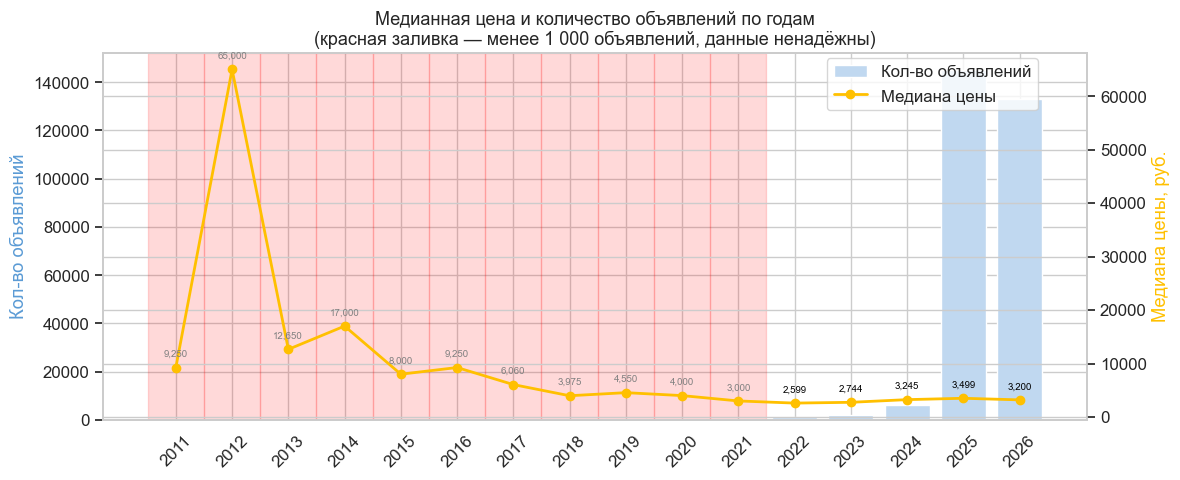

Объявлений по годам:
  2011:       2 не очень надёжный порог
  2012:       2 не очень надёжный порог
  2013:       2 не очень надёжный порог
  2014:      15 не очень надёжный порог
  2015:      21 не очень надёжный порог
  2016:      54 не очень надёжный порог
  2017:      76 не очень надёжный порог
  2018:      86 не очень надёжный порог
  2019:     158 не очень надёжный порог
  2020:     203 не очень надёжный порог
  2021:     398 не очень надёжный порог
  2022:   1,031
  2023:   1,992
  2024:   6,008
  2025: 144,988
  2026: 133,066


In [ ]:
price_valid = df[(df['price'] > 0) & (df['price'] < df['price'].quantile(0.99)) & df['created_year'].notna()]

price_by_year = price_valid.groupby('created_year')['price'].median()
count_by_year = price_valid.groupby('created_year')['price'].count()

fig, ax1 = plt.subplots(figsize=(12, 5))

MIN_COUNT = 1000

# Столбцы — количество объявлений (левая ось)
ax1.bar(count_by_year.index.astype(str), count_by_year.values,
        color='#c0d8f0', edgecolor='white', label='Кол-во объявлений')
ax1.set_ylabel('Кол-во объявлений', color='#5b9bd5')
ax1.tick_params(axis='x', rotation=45)

# Линия — медианная цена (правая ось)
ax2 = ax1.twinx()
ax2.plot(price_by_year.index.astype(str), price_by_year.values,
         marker='o', color='#ffc000', linewidth=2, label='Медиана цены')
for yr, price in price_by_year.items():
    cnt = count_by_year[yr]
    ax2.annotate(f'{price:,.0f}',
                 xy=(list(price_by_year.index).index(yr), price),
                 xytext=(0, 8), textcoords='offset points',
                 ha='center', fontsize=7,
                 color='black' if cnt >= MIN_COUNT else 'grey')
ax2.set_ylabel('Медиана цены, руб.', color='#ffc000')

# Минимальный порог надёжности
for yr, cnt in count_by_year.items():
    if cnt < MIN_COUNT:
        ax1.axvspan(list(count_by_year.index).index(yr) - 0.5,
                    list(count_by_year.index).index(yr) + 0.5,
                    alpha=0.15, color='red')

ax1.set_title('Медианная цена и количество объявлений по годам\n(красная заливка — менее 1 000 объявлений, данные ненадёжны)')
fig.legend(loc='upper right', bbox_to_anchor=(0.88, 0.88))
plt.tight_layout()
plt.show()

print('Объявлений по годам:')
for yr, cnt in count_by_year.items():
    flag = ' не очень надёжный порог' if cnt < MIN_COUNT else ''
    print(f'  {yr:.0f}: {cnt:>7,}{flag}')

In [ ]:
reliable = count_by_year[count_by_year >= MIN_COUNT].index.astype(int).tolist()
unreliable = count_by_year[count_by_year < MIN_COUNT].index.astype(int).tolist()

print(f'Надёжных лет (>= {MIN_COUNT:,} объявлений): {sorted(reliable)}')
print(f'Ненадёжных лет: {sorted(unreliable)}')
print()

print('Медианная цена по надёжным годам:')
for yr in sorted(reliable):
    price = price_by_year[yr]
    cnt   = count_by_year[yr]
    print(f'  {int(yr)}: {price:>8,.0f} руб.  ({cnt:,} объявлений)')


Надёжных лет (>= 1,000 объявлений): [2022, 2023, 2024, 2025, 2026]
Ненадёжных лет: [2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021]

Медианная цена по надёжным годам:
  2022:    2,599 руб.  (1,031 объявлений)
  2023:    2,744 руб.  (1,992 объявлений)
  2024:    3,245 руб.  (6,008 объявлений)
  2025:    3,499 руб.  (144,988 объявлений)
  2026:    3,200 руб.  (133,066 объявлений)


Выводы по распределению данных во времени:


  Надёжных лет (>= 1,000 объявлений): [2022, 2023, 2024, 2025, 2026]
  
  Ненадёжных лет: [2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021]

  Большая часть всех данных приходится на 2022–2026 годы.
  Всё остальное — единичные объявления, статистически незначимы.

  Медианная цена в надёжных годах не сильно меняется, но имеет тенденцию к росту: ['2,599', '2,744', '3,245', '3,499'] руб. 2026 год тут не стоит учитывать, тк он только идет. Скачки в ранних годах (2012: 65 000 руб.) — артефакт малой выборки, а не реальный рыночный сигнал.

## 9. Фотографии, тип продавца, рейтинг

Три коротких среза.

**Фотографии:** количество фото — возможно важный входной признак для будущей VLM-модели. Здесь смотрим только на распределение count.

**Тип продавца:** профессиональные продавцы (`isshop = True`) как правило пишут длиннее и структурированнее. Сравниваем медианную длину описаний.

**Рейтинг продавца:** `reputationscore` — рейтинг продавца от 0 до 1. Заполнен не у всех объявлений, человек без рейтинга скорее всего еще не совершил ни одной сделки. Смотрим на распределение и связь с длиной описания — продавцы с высоким рейтингом вероятно пишут качественнее.

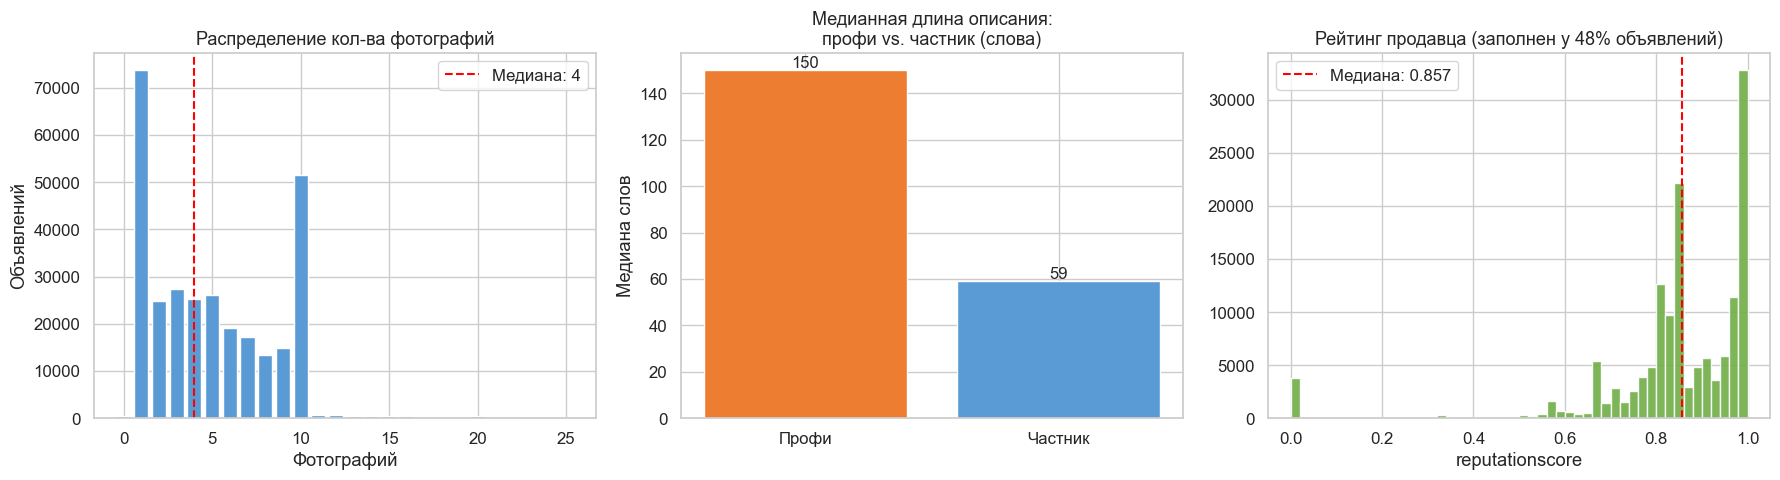

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Фотографии
max_ph = min(int(df['imagescount'].max()), 25)
ph_vc = df['imagescount'].value_counts().sort_index()
ph_vc = ph_vc[ph_vc.index <= max_ph]
axes[0].bar(ph_vc.index, ph_vc.values, color='#5b9bd5', edgecolor='white')
axes[0].set_title('Распределение кол-ва фотографий')
axes[0].set_xlabel('Фотографий')
axes[0].set_ylabel('Объявлений')
axes[0].axvline(df['imagescount'].median(), color='red', linestyle='--',
                label=f'Медиана: {df["imagescount"].median():.0f}')
axes[0].legend()

# Тип продавца: длина описания
if df['isshop'].notna().sum() > 0:
    df_pro = df[df['isshop'].notna()].copy()
    df_pro['desc_words'] = df_pro['description'].str.split().str.len()
    df_pro['seller_type'] = df_pro['isshop'].map({True: 'Профи', False: 'Частник'})
    len_by_type = df_pro.groupby('seller_type')['desc_words'].median()
    colors = ['#ed7d31', '#5b9bd5']
    axes[1].bar(len_by_type.index, len_by_type.values, color=colors, edgecolor='white')
    axes[1].set_title('Медианная длина описания:\nпрофи vs. частник (слова)')
    axes[1].set_ylabel('Медиана слов')
    for i, (k, v) in enumerate(len_by_type.items()):
        axes[1].text(i, v + 1, f'{v:.0f}', ha='center', fontsize=12)
else:
    axes[1].text(0.5, 0.5, 'Нет данных о типе продавца',
                 ha='center', va='center', transform=axes[1].transAxes)

# Рейтинг продавца
df_conv = df[df['reputationscore'].notna()]
if len(df_conv) > 0:
    axes[2].hist(df_conv['reputationscore'], bins=50, color='#70ad47', edgecolor='white', alpha=0.9)
    axes[2].axvline(df_conv['reputationscore'].median(), color='red', linestyle='--',
                    label=f'Медиана: {df_conv["reputationscore"].median():.3f}')
    axes[2].set_title(f'Рейтинг продавца (заполнен у {len(df_conv)/len(df)*100:.0f}% объявлений)')
    axes[2].set_xlabel('reputationscore')
    axes[2].legend()
else:
    axes[2].text(0.5, 0.5, 'Данные о конверсии отсутствуют',
                 ha='center', va='center', transform=axes[2].transAxes)

plt.tight_layout()
plt.show()

Выводы по трём срезам:

**Фотографии (медиана 4):**
  Распределение бимодальное: пик на 1 фото (~73k объявлений) и отдельный пик на 10 (~51k). 10 — это скорее всего лимит бесплатного размещения на Авито.

**Профи vs. частник (медиана слов: 150 vs. 59):**
  Профессиональные продавцы пишут в 2.5 раза длиннее. Это подтверждает, что `isshop` — значимый признак для `pro_score` в quality_score. `isshop` заполнен только у 27% объявлений (73% NaN), заменяем NaN на 0.5.

**Рейтинг продавца `reputationscore` (медиана 0.857):**
  Заполнен у 48% объявлений (остальные 52% — NaN, скорее всего новые продавцы без истории). Среди тех, у кого рейтинг есть распределение сконцентрировано в 0.6–1.0.

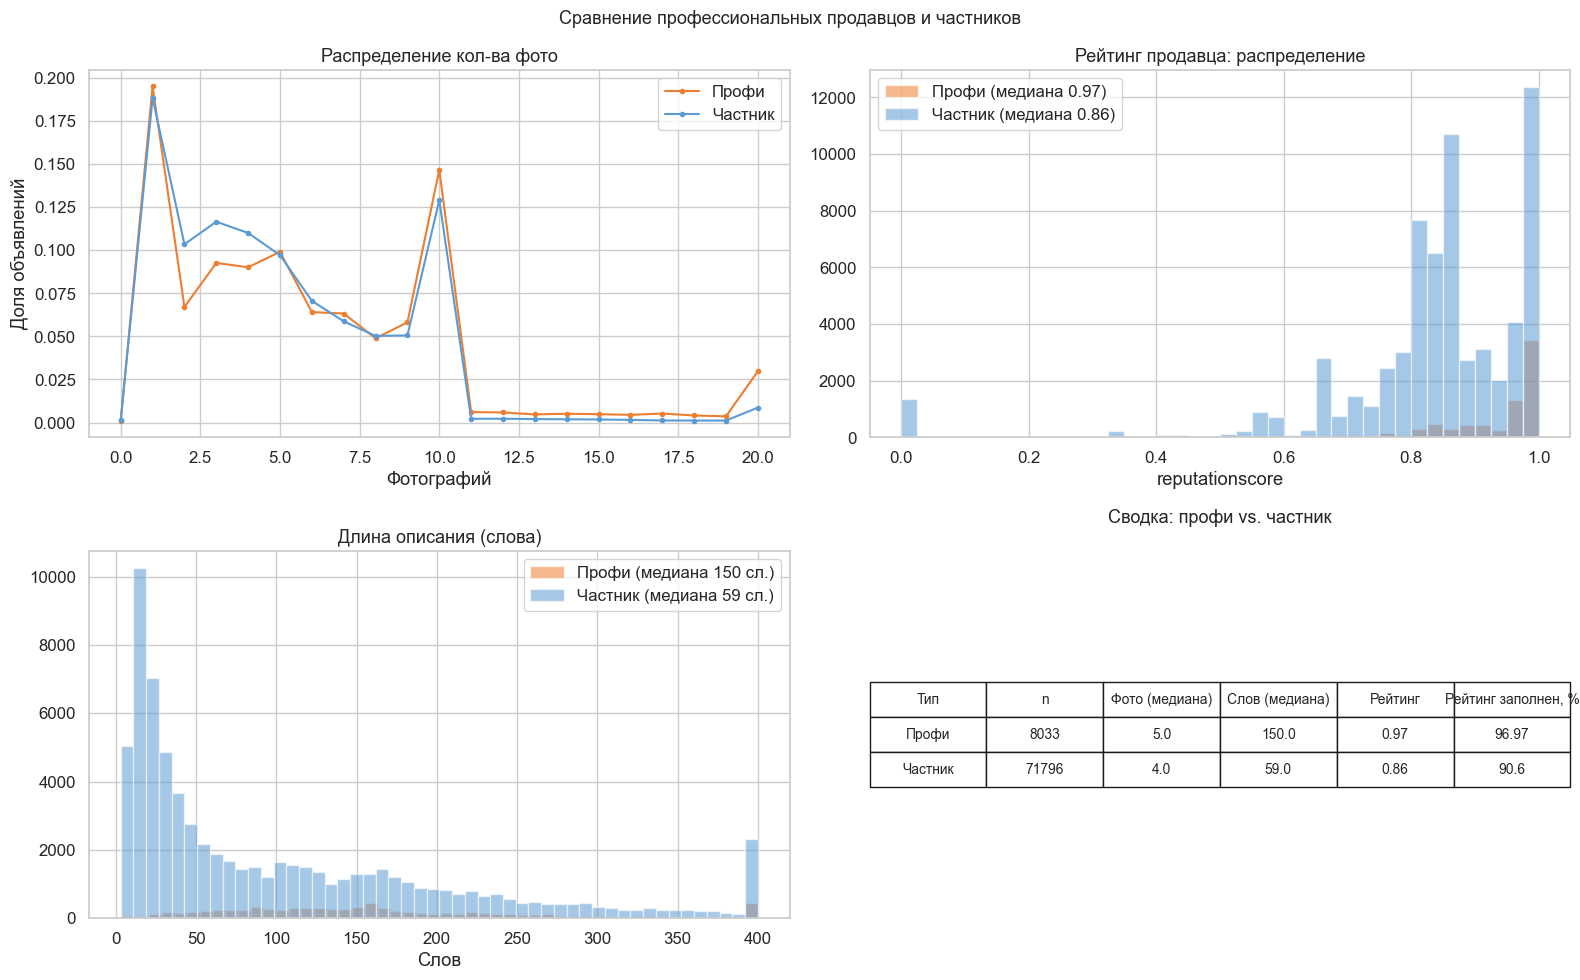

In [ ]:
df_pro_full = df[df['isshop'].notna()].copy()
df_pro_full['desc_words'] = df_pro_full['description'].apply(
    lambda x: len(x.split()) if x.strip() not in EMPTY_VALUES else 0
)
df_pro_full['seller_type'] = df_pro_full['isshop'].map({True: 'Профи', False: 'Частник'})

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

pro_colors = {'Профи': '#ed7d31', 'Частник': '#5b9bd5'}

# 1. Фотографии
for stype, grp in df_pro_full.groupby('seller_type'):
    ph = grp['imagescount'].clip(upper=20).value_counts().sort_index()
    axes[0, 0].plot(ph.index, ph.values / ph.values.sum(),
                    marker='o', markersize=3, label=stype, color=pro_colors[stype])
axes[0, 0].set_title('Распределение кол-ва фото')
axes[0, 0].set_xlabel('Фотографий')
axes[0, 0].set_ylabel('Доля объявлений')
axes[0, 0].legend()

# 2. Рейтинг продавца
df_conv_pro = df_pro_full[df_pro_full['reputationscore'].notna()]
for stype, grp in df_conv_pro.groupby('seller_type'):
    axes[0, 1].hist(grp['reputationscore'], bins=40, alpha=0.55,
                    label=f'{stype} (медиана {grp["reputationscore"].median():.2f})',
                    color=pro_colors[stype], edgecolor='white')
axes[0, 1].set_title('Рейтинг продавца: распределение')
axes[0, 1].set_xlabel('reputationscore')
axes[0, 1].legend()

# 3. Длина описания
for stype, grp in df_pro_full[df_pro_full['desc_words'] > 0].groupby('seller_type'):
    axes[1, 0].hist(grp['desc_words'].clip(upper=400), bins=50, alpha=0.55,
                    label=f'{stype} (медиана {grp["desc_words"].median():.0f} сл.)',
                    color=pro_colors[stype], edgecolor='white')
axes[1, 0].set_title('Длина описания (слова)')
axes[1, 0].set_xlabel('Слов')
axes[1, 0].legend()

# 4. Сводная таблица метрик
metrics = df_pro_full.groupby('seller_type').agg(
    n=('seller_type', 'count'),
    median_photos=('imagescount', 'median'),
    median_words=('desc_words', 'median'),
    rep_median=('reputationscore', 'median'),
    rep_fill_pct=('reputationscore', lambda x: x.notna().mean() * 100),
).round(2)

axes[1, 1].axis('off')
tbl = axes[1, 1].table(
    cellText=metrics.reset_index().values,
    colLabels=['Тип', 'n', 'Фото (медиана)', 'Слов (медиана)', 'Рейтинг', 'Рейтинг заполнен, %'],
    loc='center', cellLoc='center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1, 2)
axes[1, 1].set_title('Сводка: профи vs. частник', pad=20)

plt.suptitle('Сравнение профессиональных продавцов и частников', fontsize=13)
plt.tight_layout()
plt.show()

Выводы:

  Соотношение:  профи 8,033 (10%), частники 71,796 (90%)

  Длина описания:
    Профи пишут в 2.5 раза больше — 150 слов против 59 у частников.
    Это главное различие. У частников распределение сдвинуто влево:
    большинство пишут до 50 слов, часть не пишет вообще.

  Рейтинг продавца:
    Профи — медиана 0.97, частники — 0.86. Разрыв существенный.
    У профи рейтинг сконцентрирован у 1.0, у частников распределён шире.

  Фотографии:
    Почти одинаково — медиана 5 у профи и 4 у частников.
    Пики на 1 и 10 фото у обеих групп.

  Для файнтюна:
    Целевая аудитория проекта — частники без описания. Но учить модель
    возможно стоит на примерах профи: они пишут длиннее, структурированнее и
    имеют более высокий рейтинг. +-150 слов может быть ориентиром для генерации.
    При этом профи всего 10% датасета: есть смысл стратифицировать выборку
    так, чтобы они не были недопредставлены.

## 10. Временной анализ и скорость продажи

Смотрим на распределение объявлений по годам — актуальность данных. Чем свежее объявление, тем ближе стиль к современному.

Считаем `active_days = finishtime - starttime` — сколько дней объявление было активно. Для объявлений с `itemstatus_id == 12` (продано на Авито) это реальное время до продажи. Для остальных это просто срок жизни объявления (истечение, ручное снятие).

Надёжные годы: [2022, 2023, 2024, 2025, 2026]


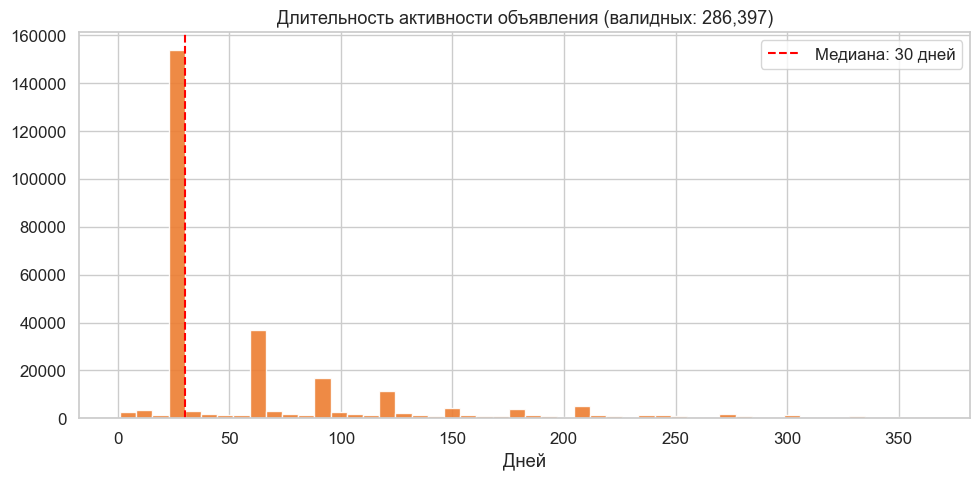

In [ ]:
RELIABLE_YEARS = df['created_year'].value_counts()
RELIABLE_YEARS = set(RELIABLE_YEARS[RELIABLE_YEARS >= 1000].index)
print(f'Надёжные годы: {sorted(RELIABLE_YEARS)}')

df['active_days'] = (df['finishtime'] - df['starttime']).dt.days
active_valid = df[(df['active_days'] > 0) & (df['active_days'] < 365)]

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(active_valid['active_days'], bins=50, color='#ed7d31', edgecolor='white', alpha=0.9)
ax.axvline(active_valid['active_days'].median(), color='red', linestyle='--',
           label=f'Медиана: {active_valid["active_days"].median():.0f} дней')
ax.set_title(f'Длительность активности объявления (валидных: {len(active_valid):,})')
ax.set_xlabel('Дней')
ax.legend()
plt.tight_layout()
plt.show()

p25 = active_valid['active_days'].quantile(0.25)
p75 = active_valid['active_days'].quantile(0.75)

Выводы по active_days:
  Медиана: 30 дней
  p25: 30 дней, p75: 90 дней

  Пик на 30 днях — стандартный срок размещения на Авито.
  Сам по себе `active_days` — зашумлённый сигнал: объявление могли снять вручную,
  оно могло истечь автоматически или продавец не продлил.

  Но есть `itemstatus_id`: для объявлений со статусом 12 (продано на Авито, 26% датасета) `active_days` — это реальное время до продажи.

#### Статус объявления (itemstatus_id)

Из документации ментора известны только 4 кода:

| Код | Значение |
|-----|----------|
| 4   | Активно |
| 12  | Продано на Авито |
| 14  | Снято продавцом |
| 15  | Продано в другом месте |

**В датасете реально встречаются:** 7 (31.2%), 12 (26.2%), 9 (19.5%), 11 (19.4%), 10536750001 (1.9%), 3 (1.0%), 10 (0.6%), 14 (0.2%), 8 (0.1%).

> Коды 4 и 15 в данных отсутствуют — датасет содержит только завершённые объявления. Значение кодов 3, 7, 8, 9, 10, 11 документацией не подтверждено.

In [ ]:
# Реальные коды в данных — смотрим прежде чем интерпретировать
print("Все значения itemstatus_id в датасете:")
vc_raw = df['itemstatus_id'].value_counts(dropna=False)
total = len(df)
for code, cnt in vc_raw.items():
    print(f"  {str(code):20s}  {cnt:>7,}  ({cnt/total*100:.1f}%)")


Все значения itemstatus_id в датасете:
  7                      93,494  (31.2%)
  12                     78,525  (26.2%)
  9                      58,402  (19.5%)
  11                     58,178  (19.4%)
  10536750001             5,641  (1.9%)
  3                       2,910  (1.0%)
  10                      1,908  (0.6%)
  14                        495  (0.2%)
  8                         447  (0.1%)


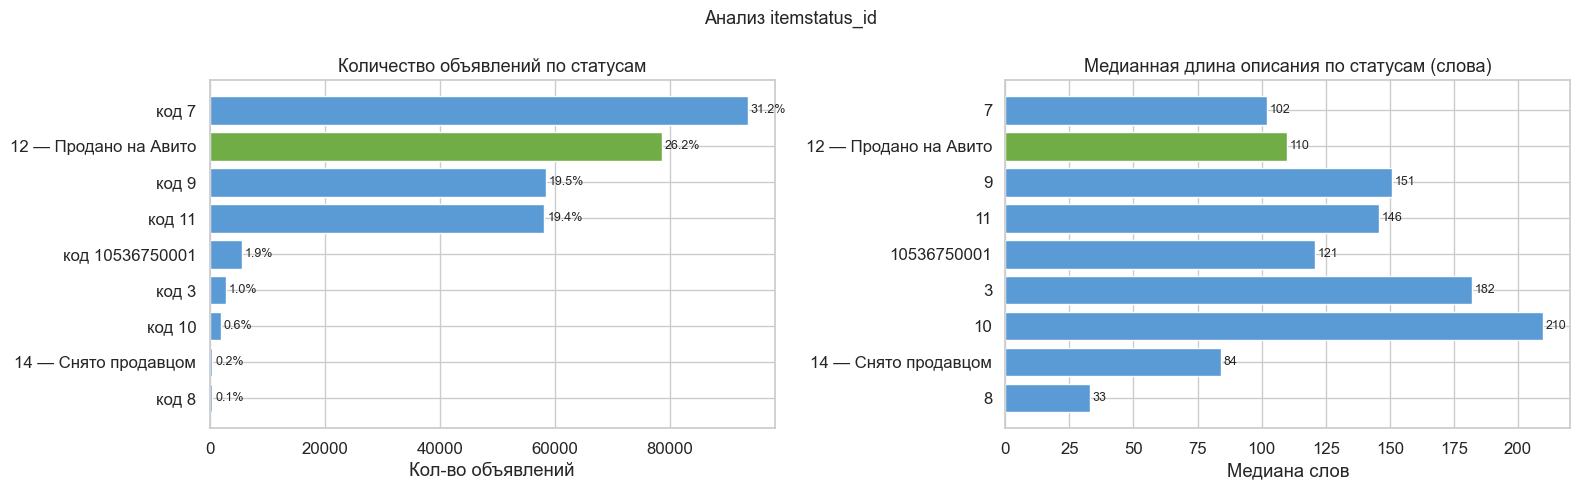

In [ ]:
KNOWN_STATUSES = {12: 'Продано на Авито', 14: 'Снято продавцом'}

vc_raw = df['itemstatus_id'].value_counts().sort_values(ascending=False)
total  = len(df)

labels = [
    f'{int(c)} — {KNOWN_STATUSES[c]}' if c in KNOWN_STATUSES else f'код {int(c)}'
    for c in vc_raw.index
]

df['_words_tmp'] = df['description'].apply(
    lambda x: len(x.split()) if x.strip() not in EMPTY_VALUES else 0
)
median_by_status = (
    df[df['_words_tmp'] > 0]
    .groupby('itemstatus_id')['_words_tmp']
    .median()
    .reindex(vc_raw.index)
)
median_labels = [
    f'{int(c)} — {KNOWN_STATUSES[c]}' if c in KNOWN_STATUSES else f'{int(c)}'
    for c in median_by_status.index
]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Левый — количество объявлений по кодам
bar_colors = ['#70ad47' if c == 12 else '#5b9bd5' for c in vc_raw.index]
axes[0].barh(labels[::-1], vc_raw.values[::-1], color=bar_colors[::-1], edgecolor='white')
for bar, v in zip(axes[0].patches, vc_raw.values[::-1]):
    axes[0].text(bar.get_width() + 500, bar.get_y() + bar.get_height() / 2,
                 f'{v/total*100:.1f}%', va='center', fontsize=9)
axes[0].set_title('Количество объявлений по статусам')
axes[0].set_xlabel('Кол-во объявлений')

# Правый — медианная длина описания по каждому коду
bar_colors2 = ['#70ad47' if c == 12 else '#5b9bd5' for c in median_by_status.index]
axes[1].barh(median_labels[::-1], median_by_status.values[::-1],
             color=bar_colors2[::-1], edgecolor='white')
for bar, v in zip(axes[1].patches, median_by_status.values[::-1]):
    axes[1].text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2,
                 f'{v:.0f}', va='center', fontsize=9)
axes[1].set_title('Медианная длина описания по статусам (слова)')
axes[1].set_xlabel('Медиана слов')

plt.suptitle('Анализ itemstatus_id', fontsize=13)
plt.tight_layout()
plt.show()


## 11. Корреляции числовых признаков

Матрица корреляций помогает понять, какие признаки связаны друг с другом и с целевой переменной (длиной описания). Это поможет при отборе входных признаков для модели.

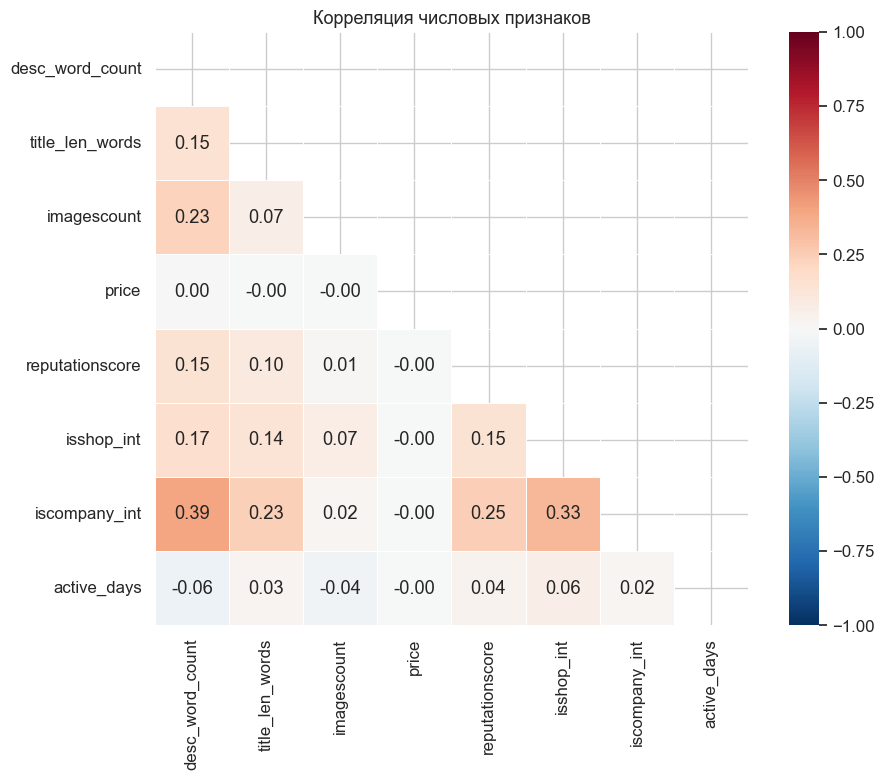

In [ ]:
df_corr = df.copy()
df_corr['desc_word_count'] = df_corr['description'].apply(
    lambda x: len(x.split()) if x.strip() not in EMPTY_VALUES else 0
)
df_corr['isshop_int']       = df_corr['isshop'].map({True: 1, False: 0})
df_corr['iscompany_int'] = df_corr['iscompany'].map({True: 1, False: 0})

num_cols = ['desc_word_count', 'title_len_words', 'imagescount', 'price',
            'reputationscore', 'isshop_int', 'iscompany_int', 'active_days']
num_cols = [c for c in num_cols if c in df_corr.columns]

corr = df_corr[num_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, mask=mask,
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Корреляция числовых признаков')
plt.tight_layout()
plt.show()

Выводы по корреляциям:

Что связано с длиной описания (`desc_word_count`):

* `iscompany_int` (0.39) — самая сильная связь. Компании и юрлица пишут заметно длиннее частников.
* `imagescount` (0.23) — больше фото = длиннее описание. Оба признака отражают одно и то же: насколько продавец старается.
* `isshop_int` (0.17) — профи-магазины пишут длиннее.
* `reputationscore` (0.15) — продавцы с высоким рейтингом чуть длиннее пишут. Связь слабая, но есть.
* `title_len_words` (0.15) — кто пишет длинный заголовок, тот и описание пишет длиннее.
* `price` (0.00) — цена вообще ни с чем не связана. Дорогие товары не получают лучших описаний.
* `active_days` (−0.06) — практически ноль. Длина описания не влияет на то, как долго объявление висит.

Все корреляции слабые или умеренные. `iscompany`, `isshop`, `imagescount` могут быть полезны как входные признаки: они говорят о стиле продавца. `price` корреляции не даёт, но семантически важен — "за 500 руб." и "за 500 000 руб." задают разный тон описания.

## 12. Информативность описания (info_ratio)

Если модель будет обучаться на примерах, где описание просто дублирует заголовок, она научится именно этому — переписывать заголовок вместо создания полезного текста.

info_ratio = (слова в описании, которых нет в заголовке) / (все слова в описании)

Показывает, какая доля слов в описании не встречается в заголовке:


Значение 1.0 — описание полностью уникально по отношению к заголовку.  
Значение 0.0 — описание целиком состоит из слов заголовка.

Мы учитываем оба алфавита (кириллица и латиница), так как в данных много технических терминов, артикулов и брендов на латинице. При длине описания менее 3 слов метрика не вычисляется (NaN) — слишком мало данных для надёжной оценки.

In [ ]:
def compute_info_ratio(title: str, description: str) -> float:
    """
    Доля слов в description, не встречающихся в title.
    Учитывает кириллические и латинские слова длиной от 2 символов.
    Возвращает NaN, если в описании менее 3 слов.
    """
    title_words = set(re.findall(r'[a-zA-Za-яёА-ЯЁ]{2,}', title.lower()))
    desc_words  = re.findall(r'[a-zA-Za-яёА-ЯЁ]{2,}', description.lower())
    if len(desc_words) < 3:
        return np.nan
    new_words = [w for w in desc_words if w not in title_words]
    return len(new_words) / len(desc_words)

# Считаем на выборке 50 000 для скорости
sample_size = min(50_000, len(df_desc))
df_sample = df_desc.sample(sample_size, random_state=42).copy()
df_sample['info_ratio'] = df_sample.apply(
    lambda r: compute_info_ratio(r['title'], r['description']), axis=1
)

print('Статистика info_ratio:')
display(df_sample['info_ratio'].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).round(3))
print(f"\nОписаний с info_ratio < 0.4 (дублируют заголовок): "
      f"{(df_sample['info_ratio'] < 0.4).sum():,} "
      f"({(df_sample['info_ratio'] < 0.4).mean()*100:.1f}%)")
print(f"Описаний с NaN (слишком короткие): "
      f"{df_sample['info_ratio'].isna().sum():,} "
      f"({df_sample['info_ratio'].isna().mean()*100:.1f}%)")

Статистика info_ratio:


count   49996.0000
mean        0.9120
std         0.1070
min         0.0000
5%          0.7110
25%         0.8900
50%         0.9440
75%         0.9750
95%         1.0000
max         1.0000
Name: info_ratio, dtype: float64


Описаний с info_ratio < 0.4 (дублируют заголовок): 316 (0.6%)
Описаний с NaN (слишком короткие): 4 (0.0%)


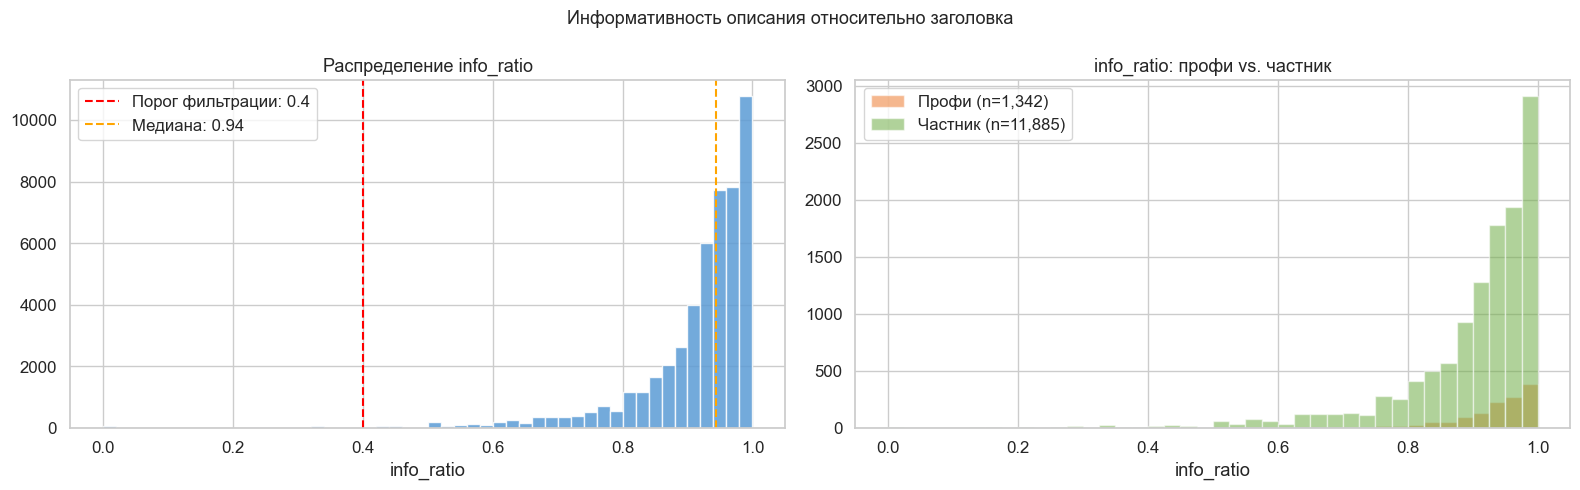

Примеры с низким info_ratio (описание почти дублирует заголовок):
  ratio=0.00 | Заголовок: Гидравлический насос R902074012 Rexroth A10VG45EP2D1/10L-NSC
           Описание:  Гидравлический насос R902074012 Rexroth A10VG45EP2D1/10L-NSC10F004DH
  ratio=0.00 | Заголовок: Вкладыши коренные 0,75 дв-406, 405, 514 Daido Metal
           Описание:  Вкладыши коренные 0,75 ДВ-406, 405, 514 Daido Metal
  ratio=0.00 | Заголовок: 6AG2193-6BP20-4BF0 купить оригинальный Siemens. Гарантия 12 
           Описание:  6AG2193-6BP20-4BF0 купить оригинальный Siemens. Гарантия 12 месяцев. С НДС и БЕЗ НДС, оплата на Р/С

Примеры с высоким info_ratio (описание раскрывает тему):
  ratio=0.97 | Заголовок: Samsung Galaxy S10+, 8/128 ГБ, 2 SIM
           Описание:  Продаю два Samsung s10+
1) изумрудный - не работает сенсор
2) синий - при увеличение яркости начинает моргать треть экрана, сенсор везде рабочий
Видео с работоспособностью по запросу
Цена за оба
Авито

  ratio=0.89 | Заголовок: Шапка uniqlo
           

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].hist(df_sample['info_ratio'].dropna(), bins=50,
             color='#5b9bd5', edgecolor='white', alpha=0.85)
axes[0].axvline(0.4, color='red', linestyle='--', label='Порог фильтрации: 0.4')
axes[0].axvline(df_sample['info_ratio'].median(), color='orange', linestyle='--',
                label=f'Медиана: {df_sample["info_ratio"].median():.2f}')
axes[0].set_title('Распределение info_ratio')
axes[0].set_xlabel('info_ratio')
axes[0].legend()

# info_ratio по типу продавца (если данные есть)
if 'isshop' in df_sample.columns and df_sample['isshop'].notna().sum() > 10:
    for lbl, color in [('Профи', '#ed7d31'), ('Частник', '#70ad47')]:
        mask = df_sample['isshop'] == (lbl == 'Профи')
        data = df_sample.loc[mask, 'info_ratio'].dropna()
        if len(data) > 0:
            axes[1].hist(data, bins=40, alpha=0.55, label=f'{lbl} (n={len(data):,})',
                        color=color, edgecolor='white')
    axes[1].set_title('info_ratio: профи vs. частник')
    axes[1].set_xlabel('info_ratio')
    axes[1].legend()
else:
    axes[1].hist(df_sample['info_ratio'].dropna(), bins=40, color='#70ad47', edgecolor='white', alpha=0.8)
    axes[1].set_title('info_ratio (все объявления)')

plt.suptitle('Информативность описания относительно заголовка', fontsize=13)
plt.tight_layout()
plt.show()

# Примеры
valid = df_sample[df_sample['info_ratio'].notna()]
print('Примеры с низким info_ratio (описание почти дублирует заголовок):')
for _, r in valid.nsmallest(3, 'info_ratio')[['title', 'description', 'info_ratio']].iterrows():
    print(f'  ratio={r["info_ratio"]:.2f} | Заголовок: {r["title"][:60]}')
    print(f'           Описание:  {r["description"][:120]}')

print('\nПримеры с высоким info_ratio (описание раскрывает тему):')
good = valid[(valid['info_ratio'] >= 0.75) & (valid['desc_len_words'] >= 20) & (valid['desc_len_words'] <= 120)]
for _, r in good.sample(min(3, len(good)), random_state=7)[['title', 'description', 'info_ratio']].iterrows():
    print(f'  ratio={r["info_ratio"]:.2f} | Заголовок: {r["title"][:60]}')
    print(f'           Описание:  {r["description"][:200]}')
    print()

Медиана info_ratio = 0.94 — описания в среднем очень информативны: 94% слов не встречаются в заголовке.
*  Ниже порога 0.4 (дублируют заголовок): ~0.6% — редкость
*  Выше 0.8 (хорошо раскрывают тему): ~90%+

Низкий info_ratio почти всегда автозапчасти или еще какие-то детали с артикулами, где заголовок и описание содержат один и тот же технический код.
Профи и частники показывают похожие распределения — дело не в типе продавца, а в категории товара.

## 13. Дубликаты описаний

Если одно и то же описание встречается у сотен разных объявлений, то это шаблон. Шаблонные описания сами по себе не плохи, они часто хорошо структурированы.
Проблема в представленности: один текст на 338 объявлений занял бы ~11%
обучающей выборки из 3000 примеров, сильно сместив генерацию в сторону этого шаблона.

Решение -- оставить каждый уникальный текст ровно один раз. Хорошая структура
попадёт в обучение, но без перекоса.

Используем MD5-хэш нормализованного текста (нижний регистр, без ведущих/хвостовых пробелов) для быстрого поиска точных дубликатов.

In [ ]:
df_desc['desc_hash'] = df_desc['description'].str.strip().str.lower().apply(
    lambda x: hashlib.md5(x.encode('utf-8')).hexdigest()
)

hash_counts = df_desc['desc_hash'].value_counts()
n_unique_desc  = (hash_counts == 1).sum()
n_dup_hashes   = (hash_counts > 1).sum()
n_dup_rows     = hash_counts[hash_counts > 1].sum()

print('Анализ дубликатов:')
print(f'  Всего описаний:                  {len(df_desc):,}')
print(f'  Уникальных (встречается 1 раз):  {n_unique_desc:,} ({n_unique_desc/len(df_desc)*100:.1f}%)')
print(f'  Неуникальных хэшей:              {n_dup_hashes:,}')
print(f'  Строк с дублированным описанием: {n_dup_rows:,} ({n_dup_rows/len(df_desc)*100:.1f}%)')

# Топ шаблонов
top_hashes = hash_counts.head(15)
hash_to_text = df_desc.drop_duplicates('desc_hash').set_index('desc_hash')['description']
print('\nТоп-10 шаблонных описаний (по числу повторений):')
for h, cnt in top_hashes.head(10).items():
    text = hash_to_text.get(h, '???')
    print(f'  [{cnt} повт.] {text[:300]}')

Анализ дубликатов:
  Всего описаний:                  300,000
  Уникальных (встречается 1 раз):  278,532 (92.8%)
  Неуникальных хэшей:              5,481
  Строк с дублированным описанием: 21,468 (7.2%)

Топ-10 шаблонных описаний (по числу повторений):
  [338 повт.] Огромные чисто-белые круглые цветки
В продаже взрослое растение с 1 цветоносом - сейчас начало цвести.
Корни в хорошем состоянии, пересадка не нужна.
Высота цветоносов около 70 см, размер цветков около 12 см.
Легко растёт и цветёт в комнате.
Освещение умеренное на восточном или западном окне.
Полива
  [188 повт.] Продам ноутбук, покупал год назад, windows7 лицензия, работает хорошо, нариканий нет
Процессор Intel Core i3 2370M
Экран 15.6
Видеокарта Radeon 1gb
Жесткий диск 500гб
Оперативная память 4gb
В подарок беспроводная мышка Logitech
Тестовое объявление, не трогайте, читайте комментарии в инфе о юзере, об
  [175 повт.] Гарантия Качества: Ремонтные Пороги и Арки (Точная Геометрия) | От Экспертов 🤝

Почему нам доверяют тыс

7.2% описаний — точные дубликаты (21,468 строк, 5,481 уникальных шаблонов).
92.8% уникальны — для датасета такого размера это хороший показатель.

В топе шаблонов большинство — профессиональные продавцы, которые используют один текст для сотен объявлений.
> Тестовое объявление, не трогайте, читайте комментарии в инфе о юзере

Или это какой-то скам. В любом случае много экземпляров таких сообщений не должно попасть в выборку.

## 14. Составной балл качества — первая итерация

Собираем все сигналы в один числовой балл от 0 до 1. Веса пока интуитивные — грубо равные, без опоры на данные:

| Компонент | Вес | Что измеряет |
|---|---|---|
| `desc_length_score` | 0.20 | Длина описания (оптимум 30–150 слов) |
| `recency_score` | 0.15 | Свежесть: 2025–2026 приоритетны |
| `info_ratio_qs` | 0.15 | Описание добавляет инфо сверх заголовка |
| `reputation_score` | 0.15 | Рейтинг продавца |
| `speed_score` | 0.15 | Быстрое снятие — вероятно продажа |
| `pro_score` | 0.10 | Профи-продавец (`isshop`) |
| `images_score` | 0.05 | Кол-во фотографий (0–10) |
| `no_contacts` | 0.05 | Нет внешних ссылок и телефонов |

После того как посмотрим на разброс каждого компонента — пересмотрим веса в секции 15.

In [ ]:
print('Первая итерация quality_score')
df_qs = df.copy()
df_qs['desc_words_qs'] = df_qs['description'].str.split().str.len()
df_qs['info_ratio_qs'] = df_qs.apply(
    lambda r: compute_info_ratio(r['title'], r['description']), axis=1
).fillna(0.5)

# Рейтинг продавца
rep_max = df_qs['reputationscore'].quantile(0.99)
df_qs['reputation_score'] = (
    df_qs['reputationscore'].clip(upper=rep_max) / (rep_max + 1e-9)
).fillna(0.5)

# Скорость (меньше дней = выше балл)
if 'active_days' in df_qs.columns:
    df_qs['speed_score'] = (
        1 - df_qs['active_days'].clip(1, 364).rank(pct=True)
    ).fillna(0.5)
else:
    df_qs['speed_score'] = 0.5

# Длина
def length_score(w):
    if 30 <= w <= 150: return 1.0
    return max(0.0, 1 - abs(w - (30 if w < 30 else 150)) / 80)
df_qs['desc_length_score'] = df_qs['desc_words_qs'].apply(length_score)

# Профи-продавец
df_qs['pro_score'] = df_qs['isshop'].map({True: 1.0, False: 0.3}).fillna(0.5)

# Нет контактов
contact_re = r'(http|www\.|\+7|8[- ]?\(?9|t\.me|vk\.com|@)'
df_qs['no_contacts'] = (~df_qs['description'].str.contains(
    contact_re, case=False, regex=True, na=False
)).astype(float)

# Фотографии
df_qs['images_score'] = df_qs['imagescount'].clip(0, 10) / 10

# Свежесть
if 'created_year' in df_qs.columns:
    df_qs['recency_score'] = df_qs['created_year'].apply(
        lambda y: 1.0 if y >= 2025 else (0.5 if y == 2024 else (0.2 if y >= 2022 else 0.0))
    ).fillna(0.5)
else:
    df_qs['recency_score'] = 0.5

# Первая версия весов — интуитивные
W = {
    'desc_length_score': 0.20,
    'recency_score':     0.15,
    'info_ratio_qs':     0.15,
    'reputation_score':  0.15,
    'speed_score':       0.15,
    'pro_score':         0.10,
    'images_score':      0.05,
    'no_contacts':       0.05,
}
df_qs['quality_score'] = sum(df_qs[col] * w for col, w in W.items())

print('Статистика quality_score (первая итерация):')
display(df_qs['quality_score'].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95]).round(3))


Первая итерация quality_score
Статистика quality_score (первая итерация):


count   300000.0000
mean         0.7110
std          0.0950
min          0.2720
10%          0.5790
25%          0.6410
50%          0.7240
75%          0.7840
90%          0.8260
95%          0.8490
max          0.9950
Name: quality_score, dtype: float64

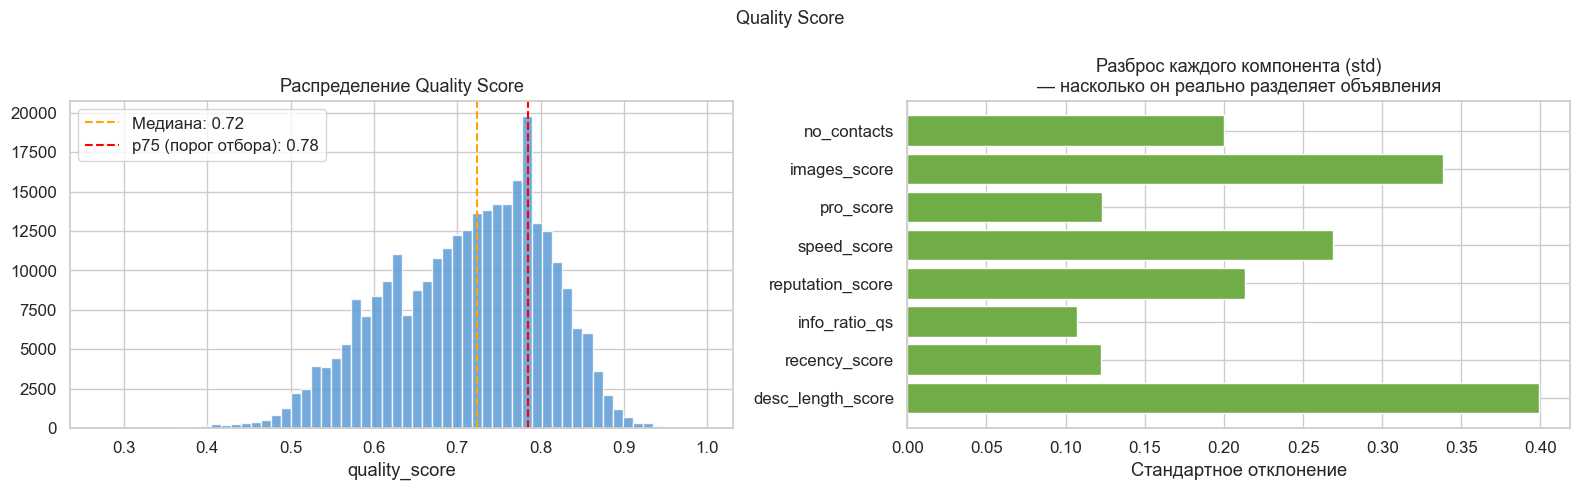

In [ ]:
component_stds = {col: df_qs[col].std() for col in W.keys()}

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].hist(df_qs['quality_score'], bins=60, color='#5b9bd5', edgecolor='white', alpha=0.85)
for pct, color, lbl in [(0.5, 'orange', 'Медиана'), (0.75, 'red', 'p75 (порог отбора)')]:
    v = df_qs['quality_score'].quantile(pct)
    axes[0].axvline(v, color=color, linestyle='--', label=f'{lbl}: {v:.2f}')
axes[0].set_title('Распределение Quality Score')
axes[0].set_xlabel('quality_score')
axes[0].legend()

# Сила каждого компонента
axes[1].barh(list(component_stds.keys()), list(component_stds.values()),
             color='#70ad47', edgecolor='white')
axes[1].set_title('Разброс каждого компонента (std)\n— насколько он реально разделяет объявления')
axes[1].set_xlabel('Стандартное отклонение')

plt.suptitle('Quality Score', fontsize=13)
plt.tight_layout()
plt.show()

Что видим на графике разброса компонентов:

* `desc_length_score` — самый высокий std (~0.40). Длины описаний сильно разбросаны, этот компонент реально разделяет объявления.
* `images_score` — второй по силе (~0.34).
* `speed_score` — хороший разброс (~0.27).
* `reputation_score` и `no_contacts` — умеренные (~0.20–0.21).
* `recency_score` и `pro_score` — слабые (~0.12).
* `info_ratio_qs` — самый слабый (~0.11), тк 90%+ описаний уже имеют высокий info_ratio.

Веса выставлены интуитивно, без опоры на реальный разброс.Попробуем перераспределить: дадим больший вес сильным компонентам, уберём `recency_score` в фильтр и добавим `sold_score`.

## 15. Quality Score — финальная версия

По итогам анализа разброса:

* `recency_score` убираем из балла — после 2025 года он почти не дискриминирует
* Добавляем `sold_score` (`itemstatus_id == 12`) — реальная подтверждённая продажа, бинарный признак с высоким разбросом
* Перераспределяем веса в пользу сильных компонентов: `desc_length_score` и `sold_score` — лидеры; `no_contacts` (std 0.20) получает больше чем `pro_score` (std 0.12)

In [ ]:
# Добавляем сигналы которых не было в первой итерации
df_qs['sold_score']   = (df_qs['itemstatus_id'] == 12).astype(float)
df_qs['images_score'] = df_qs['imagescount'].clip(0, 10) / 10  # уже есть, переписываем явно

# Веса — пропорциональны реальному разбросу (std) каждого компонента
W = {
    'desc_length_score': 0.25,
    'sold_score':        0.15,
    'speed_score':       0.15,
    'reputation_score':  0.10,
    'images_score':      0.10,
    'no_contacts':       0.10,
    'pro_score':         0.10,  # std 0.12 > info_ratio_qs std 0.11
    'info_ratio_qs':     0.05,  # std 0.11, самый слабый дискриминатор
}
w_sum = sum(W.values())
df_qs['quality_score'] = sum(df_qs[col] * w / w_sum for col, w in W.items())

print('Статистика обновлённого quality_score:')
display(df_qs['quality_score'].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95]).round(3))

component_stds = {col: df_qs[col].std() for col in W.keys()}
print('\nРазброс компонентов финальной версии:')
for col, std in sorted(component_stds.items(), key=lambda x: -x[1]):
    print(f'  {col:<22} std = {std:.3f}   вес = {W[col]/w_sum:.2f}')


Статистика обновлённого quality_score:


count   300000.0000
mean         0.5860
std          0.1250
min          0.1270
10%          0.4060
25%          0.5000
50%          0.6020
75%          0.6730
90%          0.7410
95%          0.7780
max          0.9570
Name: quality_score, dtype: float64


Разброс компонентов финальной версии:
  sold_score             std = 0.440   вес = 0.15
  desc_length_score      std = 0.399   вес = 0.25
  images_score           std = 0.339   вес = 0.10
  speed_score            std = 0.269   вес = 0.15
  reputation_score       std = 0.213   вес = 0.10
  no_contacts            std = 0.200   вес = 0.10
  pro_score              std = 0.123   вес = 0.10
  info_ratio_qs          std = 0.107   вес = 0.05


## 16. Баланс категорий по уровню качества

Проверяем, равномерно ли распределены хорошие объявления с высоким quality_score по категориям. Если в каких-то категориях почти нет высококачественных примеров, модель будет плохо генерировать для них.

Делим quality_score на три уровня по терцилям и строим тепловую карту.

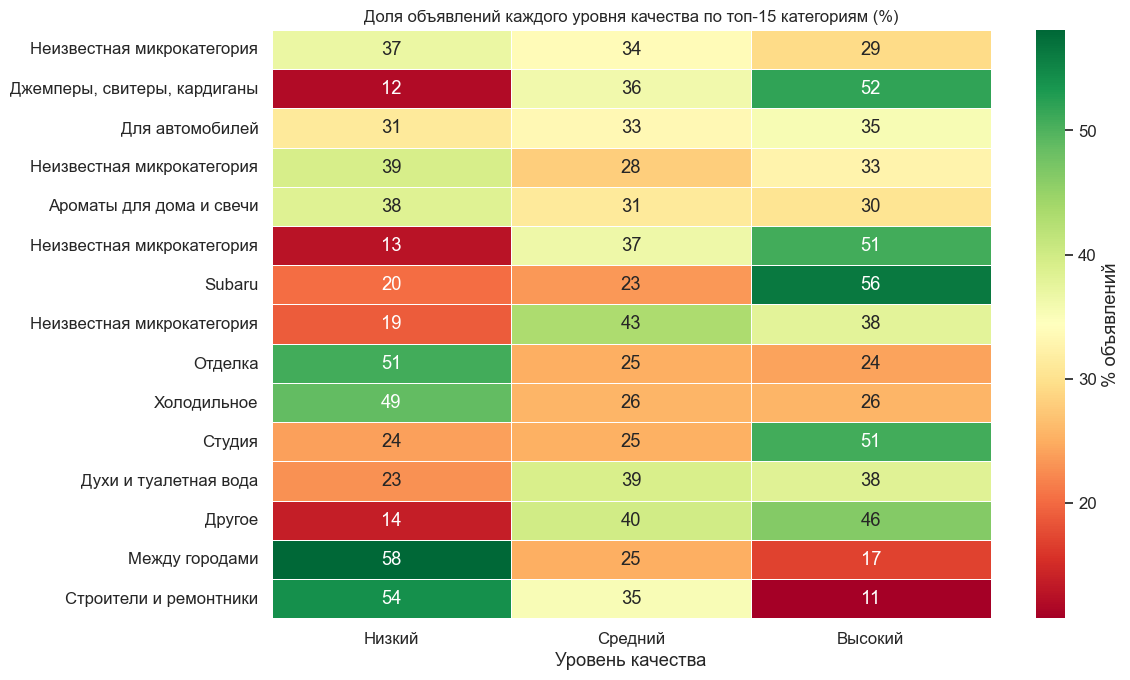

In [ ]:
q33 = df_qs['quality_score'].quantile(0.33)
q66 = df_qs['quality_score'].quantile(0.66)
df_qs['quality_tier'] = pd.cut(
    df_qs['quality_score'],
    bins=[-np.inf, q33, q66, np.inf],
    labels=['Низкий', 'Средний', 'Высокий']
)

top_cats = df_qs['category_id'].value_counts().head(15).index
heatmap_data = (
    df_qs[df_qs['category_id'].isin(top_cats)]
    .groupby(['category_id', 'quality_tier'], observed=True)
    .size()
    .unstack(fill_value=0)
)
heatmap_pct = heatmap_data.div(heatmap_data.sum(axis=1), axis=0) * 100

# Именуем категории по microcat_name
cat_name_map = (
    df_qs[df_qs['category_id'].isin(top_cats)]
    .drop_duplicates('category_id')
    .set_index('category_id')['microcat_name']
)
heatmap_pct.index = [
    cat_name_map.get(cid, str(int(cid))) for cid in heatmap_pct.index
]

fig, ax = plt.subplots(figsize=(12, 7))
sns.heatmap(heatmap_pct, annot=True, fmt='.0f', cmap='RdYlGn',
            ax=ax, linewidths=0.5, cbar_kws={'label': '% объявлений'})
ax.set_title('Доля объявлений каждого уровня качества по топ-15 категориям (%)', fontsize=12)
ax.set_xlabel('Уровень качества')
ax.set_ylabel('')
plt.tight_layout()
plt.show()


Хорошие источники (много "высокого"):


*  Джемперы, свитеры, кардиганы — 52% высокий, только 12% низкий. Лучшая категория.

*  Subaru — 56% высокий. Скорее всего запчасти: продавцы пишут подробно (артикул, состояние, совместимость).

*  Студия и ещё одна неизвестная микрокатегория — по 51% высокий.

Проблемные (много "низкого"):

*  Между городами — 58% низкий, 17% высокий. Это грузоперевозки: короткие объявления-услуги, не товары.

*  Строители и ремонтники — 54% низкий, 11% высокий. Та же история — услуги.

*  Отделка и Холодильное — ~50% низкий. Технические описания с артикулами, шаблонный язык.

*  Неизвестная микрокатегория — встречается 4 раза. Это объявления без совпадения в справочнике микрокатегорий (~10%
датасета). Качество у них разное — от хорошего до плохого.

Вывод: "Между городами" и "Строители и ремонтники" — кандидаты на исключение (услуги, не товары). Остальные берём с отбором по quality_score.

Качество объявлений заметно варьируется по категориям — распределение неравномерное.

- в одних категориях большинство объявлений попадает в "высокий" уровень: продавцы там пишут подробно, фото много, скорость снятия быстрая
- в других доминирует "низкий": короткие описания, мало фото, шаблонный текст

Для файнтюна это важно: если брать равную квоту по категориям, из "слабых" категорий в выборку попадёт много посредственных примеров. Поэтому в секции 17 отбираем топ по quality_score внутри каждой категории — а не просто первые N строк.

## 17. Формирование обучающей выборки

Применяем последовательные фильтры, затем из оставшегося пула берём топ по `quality_score` с равномерной квотой по категориям.

Фильтры:

- **F0** — есть изображение в архиве (~262k из 300k)
- **F1** — описание присутствует
- **F2** — описание ≥ 10 слов
- **F3** — описание ≤ p99 по словам
- **F4** — цена > 0
- **F5** — нет внешних контактов, ссылок, телефонов
- **F6** — уникальное описание (без точных дубликатов)
- **F7** — только данные 2025+
- **F8** — исключены нетоварные категории (услуги, работа, готовый бизнес, билеты)

`reputationscore` NaN не фильтруется жёстко — в quality_score такие строки получают `reputation_score = 0.5` (нейтральный балл).

In [ ]:
print('Воронка отбора:')
print(f'Исходный размер: {len(df):,}')

f0 = df['has_image']
print(f'F0 — есть изображение:             {f0.sum():,} ({f0.mean()*100:.1f}%)')
# reputationscore NaN не фильтруем — в quality_score → reputation_score = 0.5

df['_desc_words'] = df['description'].apply(
    lambda x: len([t for t in re.split(r'[\s,;.!?|:]+', x)
                   if re.sub(r'^\W+|\W+$', '', t)])
    if x.strip() not in EMPTY_VALUES else 0
)

f1 = f0
print(f'F1 — есть описание:               {f1.sum():,} ({f1.mean()*100:.1f}%)')

f2 = f1 & (df['_desc_words'] >= 10)
print(f'F2 — описание >= 10 слов:          {f2.sum():,} ({f2.mean()*100:.1f}%)')

max_words = df.loc[f1, '_desc_words'].quantile(0.99)
f3 = f2 & (df['_desc_words'] <= max_words)
print(f'F3 — описание <= {max_words:.0f} слов (p99):  {f3.sum():,} ({f3.mean()*100:.1f}%)')

f4 = f3 & (df['price'] > 0) & df['price'].notna()
print(f'F4 — цена > 0:                     {f4.sum():,} ({f4.mean()*100:.1f}%)')

contact_mask = df['description'].str.contains(
    r'(http|www\.|\+7|8[- ]?\(?9|t\.me|vk\.com|@)', case=False, regex=True, na=False
)
f5 = f4 & ~contact_mask
print(f'F5 — нет внешних контактов:        {f5.sum():,} ({f5.mean()*100:.1f}%)')

df_f5 = df[f5].copy()
df_f5['_hash'] = df_f5['description'].str.strip().str.lower().apply(
    lambda x: hashlib.md5(x.encode('utf-8')).hexdigest()
)
hash_counts_f5 = df_f5['_hash'].value_counts()
unique_set = set(hash_counts_f5[hash_counts_f5 == 1].index)
f6_idx = df_f5[df_f5['_hash'].isin(unique_set)].index
f6 = df.index.isin(f6_idx)
print(f'F6 — уникальное описание:          {f6.sum():,} ({f6.mean()*100:.1f}%)')

if 'created_year' in df.columns:
    f7 = f6 & (df['created_year'] >= 2025)
    print(f'F7 — данные 2025+:                 {f7.sum():,} ({f7.mean()*100:.1f}%)')
    excl_biz    = (df['microcat_subcat'] == 'Готовый бизнес').fillna(False)
    excl_hobby  = (df['microcat_subcat'] == 'Билеты и путешествия').fillna(False)
    f8 = f7 & ~df['category_id'].isin(EXCLUDED_CAT_IDS) & ~excl_biz & ~excl_hobby
    print(f'F8 — исключены нетоварные категории: {f8.sum():,} ({f8.mean()*100:.1f}%)')
    print(f'     (услуги, работа, готовый бизнес, билеты/путешествия)')
    final_filter = f8
else:
    final_filter = f6
print(f'\nПосле всех фильтров: {final_filter.sum():,} объявлений')

Воронка отбора:
Исходный размер: 300,000
F0 — есть изображение:             262,776 (87.6%)
F1 — есть описание:               262,776 (87.6%)
F2 — описание >= 10 слов:          254,928 (85.0%)
F3 — описание <= 548 слов (p99):  252,306 (84.1%)
F4 — цена > 0:                     245,181 (81.7%)
F5 — нет внешних контактов:        235,082 (78.4%)
F6 — уникальное описание:          219,162 (73.1%)
F7 — данные 2025+:                 210,367 (70.1%)
F8 — исключены нетоварные категории: 190,345 (63.4%)
     (услуги, работа, готовый бизнес, билеты/путешествия)

После всех фильтров: 190,345 объявлений


Пул после фильтрации: 190,345 объявлений
Категорий: 45, квота на категорию: 66

Итоговый датасет: 2,937 строк
Средний quality_score:   0.805
Медиана слов:            66


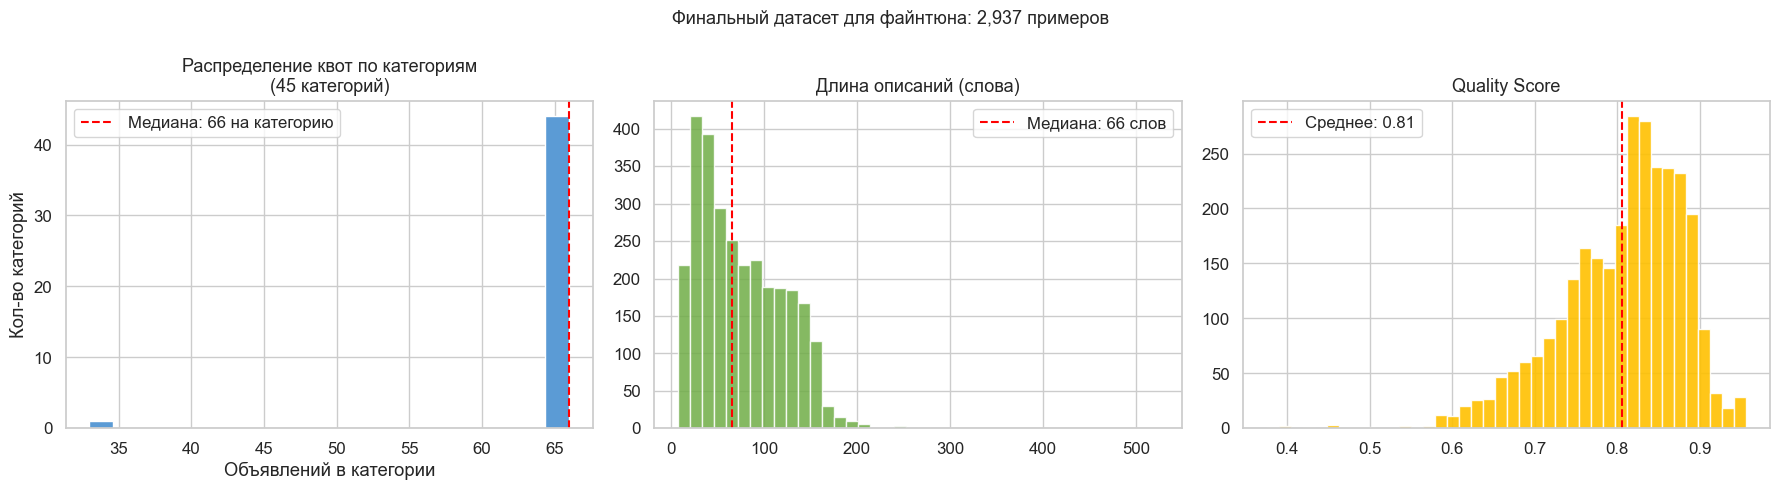

In [ ]:
TARGET_TOTAL = 3000

# Берём пересечение отфильтрованных строк с рассчитанным quality_score
df_pool = df_qs[df_qs.index.isin(df[final_filter].index)].copy()
print(f'Пул после фильтрации: {len(df_pool):,} объявлений')

n_cats = df_pool['category_id'].nunique()
per_cat = TARGET_TOTAL // n_cats
print(f'Категорий: {n_cats}, квота на категорию: {per_cat}')

frames = []
for _, grp in df_pool.groupby('category_id'):
    n_take = min(per_cat, len(grp))
    frames.append(grp.nlargest(n_take, 'quality_score'))

df_finetune = pd.concat(frames).drop_duplicates()

print(f'\nИтоговый датасет: {len(df_finetune):,} строк')
print(f'Средний quality_score:   {df_finetune["quality_score"].mean():.3f}')
print(f'Медиана слов:            {df_finetune["desc_words_qs"].median():.0f}')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Гистограмма квот по категориям вместо barh
cat_counts_fin = df_finetune['category_id'].value_counts()
axes[0].hist(cat_counts_fin.values, bins=20, color='#5b9bd5', edgecolor='white')
axes[0].axvline(cat_counts_fin.median(), color='red', linestyle='--',
                label=f'Медиана: {cat_counts_fin.median():.0f} на категорию')
axes[0].set_title(f'Распределение квот по категориям\n({cat_counts_fin.shape[0]} категорий)')
axes[0].set_xlabel('Объявлений в категории')
axes[0].set_ylabel('Кол-во категорий')
axes[0].legend()

axes[1].hist(df_finetune['desc_words_qs'], bins=40, color='#70ad47', edgecolor='white', alpha=0.85)
axes[1].axvline(df_finetune['desc_words_qs'].median(), color='red', linestyle='--',
                label=f'Медиана: {df_finetune["desc_words_qs"].median():.0f} слов')
axes[1].set_title('Длина описаний (слова)')
axes[1].legend()

axes[2].hist(df_finetune['quality_score'], bins=40, color='#ffc000', edgecolor='white', alpha=0.9)
axes[2].axvline(df_finetune['quality_score'].mean(), color='red', linestyle='--',
                label=f'Среднее: {df_finetune["quality_score"].mean():.2f}')
axes[2].set_title('Quality Score')
axes[2].legend()

plt.suptitle(f'Финальный датасет для файнтюна: {len(df_finetune):,} примеров', fontsize=13)
plt.tight_layout()
plt.show()

# Сохранение
cols_to_save = ['item_id', 'image_id', 'title', 'description',
                'category_id', 'category_name', 'microcat_id', 'microcat_name',
                'itemstatus_id', 'price', 'imagescount',
                'isshop', 'iscompany', 'hasbusinessprofile',
                'reputationscore', 'starttime', 'quality_score']
cols_to_save = [c for c in cols_to_save if c in df_finetune.columns]
df_finetune[cols_to_save].to_csv(OUTPUT_PATH, index=False, encoding='utf-8-sig')

## 18. Итоги

Датасет — 300k объявлений с Авито. Задача была отобрать из них ~3k примеров для файнтюна модели, которая будет генерировать описания товаров по фото и заголовку.
Сначала разобралась с колонками, потом присоединила справочник микрокатегорий — теперь видно не просто id, а названия.
Посмотрела на целевую переменную — описание. Медиана 59 слов, но разброс огромный: есть тексты на 500+ слов. Из паттернов: около 10% объявлений содержат телефоны, ссылки или контакты в описании — это не то что нужно модели, убрала фильтром.
Пропуски: reputationscore отсутствует у 52% строк — это новые продавцы без истории. Жёстко не фильтровала, просто дала им нейтральный балл 0.5 в quality_score. isshop и iscompany заполнила False там где пусто.
Посмотрела на категории. Транспорт занимает 42% датасета — без стратификации модель бы обучалась почти только на описаниях запчастей. Исключила нетоварные категории: услуги, вакансии, готовый бизнес, билеты и путешествия. Это важно: у них другой язык и структура, обучать модель на них не имеет смысла.
7.2% описаний — точные дубликаты, шаблоны. Один текст мог встречаться у 300+ объявлений. Оставила каждый уникальный текст ровно один раз.
Для quality_score сделала две итерации. В первой веса были интуитивные, recency_score стоял как отдельный компонент. Посмотрела на реальный разброс (std) каждого компонента и увидела, что recency_score почти не дискриминирует — после фильтра F7 (только 2025+) все объявления и так свежие. Убрала его из балла, вынесла в фильтр. Вместо него добавила sold_score: itemstatus_id == 12 означает реальную продажу на Авито, это самый сильный сигнал в итоге (std 0.44). Веса расставила по убыванию реального разброса.

Финальная воронка: 300k -> ~108k после всех фильтров. Из этого пула взяла топ по quality_score с квотой ~62 объявления на категорию. Итого ~3k примеров, покрытие почти полное.